Building upstream cache (OCR -> corrector -> classifier -> enricher) ...


INFO | [PaddleOCR] '1.png' (2682x1600px)


  cached 57/57 images in 197.5s

  REFERENCE — geometric cy/cx (current default mode)
  4F-F1= 40.7%   3F-F1= 43.0%   P=39.7  R=41.8   pred= 912   (0.33s)

  AXIS — row_overlap_min   (others held: row=0.5 col=0.3 ctx=0.2)
  row_overlap_min=0.3   4F-F1= 42.3%  3F-F1= 44.1%  P=42.2 R=42.4  pred= 869  Δvsref= +1.6pp  (0.31s)
  row_overlap_min=0.4   4F-F1= 42.3%  3F-F1= 44.2%  P=43.2 R=41.4  pred= 831  Δvsref= +1.6pp  (0.31s)
  row_overlap_min=0.5   4F-F1= 42.0%  3F-F1= 43.3%  P=43.7 R=40.4  pred= 801  Δvsref= +1.3pp  (0.31s)
  row_overlap_min=0.6   4F-F1= 41.2%  3F-F1= 42.4%  P=44.7 R=38.2  pred= 741  Δvsref= +0.5pp  (0.3s)
  row_overlap_min=0.7   4F-F1= 38.8%  3F-F1= 40.2%  P=44.3 R=34.5  pred= 675  Δvsref= -1.9pp  (0.29s)
  -> best row_overlap_min = 0.3  @ 4F-F1=42.3%

  AXIS — col_overlap_min   (others held: row=0.5 col=0.3 ctx=0.2)
  col_overlap_min=0.2   4F-F1= 42.0%  3F-F1= 43.3%  P=43.7 R=40.4  pred= 801  Δvsref= +1.3pp  (0.3s)
  col_overlap_min=0.3   4F-F1= 42.0%  3F-F1= 43.3%  P=

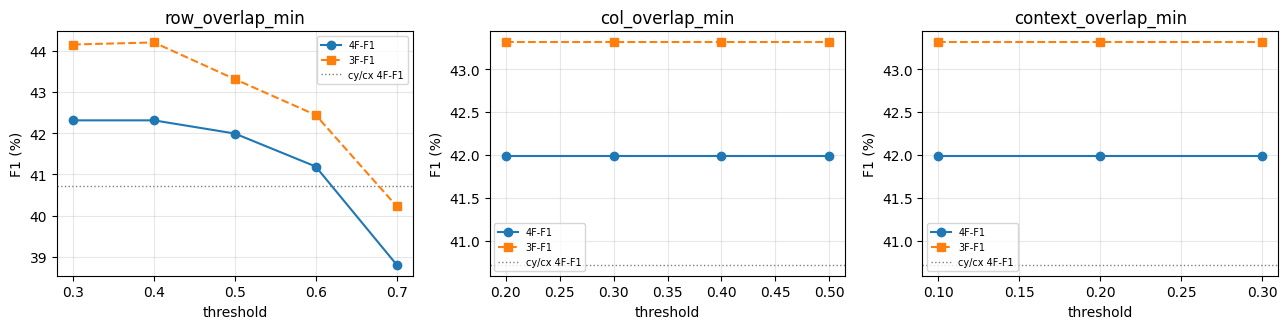

In [1]:
# =====================================================================
#  OVERLAP-MODE THRESHOLD SWEEP  —  Graph V2 + Association V2
#  Axes: row_overlap_min / col_overlap_min / context_overlap_min
#
#  EVALUATOR: your deterministic path — LLMTupleEvaluator(use_llm=False).
#  No LLM, no Ollama (with use_llm=False, _call_ollama is never reached).
#  Numbers are on the SAME evaluator that produced the exp* ladder, so the
#  cy/cx reference here should line up with your historical cy/cx number.
#
#  WHAT IT DOES
#  ------------
#  Upstream (PaddleOCR -> corrector_v2 -> rule-based classifier -> enricher)
#  does NOT depend on the overlap thresholds, so it runs ONCE per image and is
#  cached. Only Graph V2 + Association V2 + eval re-run per configuration.
#  Re-running this cell reuses the cache (delete ENRICHED_CACHE to rebuild).
#
#  Per-axis grid: the two axes NOT being swept are held at the overlap
#  defaults (0.50 / 0.30 / 0.20). cy/cx is run as an in-harness reference.
#
#  REQUIRES: the UPDATED graph_constructor_v2.py (overlap mode) in src/graph/.
#  Run the notebook from the project root.
# =====================================================================

import os, sys, csv, time, io, tempfile, contextlib
from pathlib import Path

sys.path.insert(0, '.')

# ── Stage imports (mirror run_graph_v2_experiment.py wiring) ─────────
from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens      # canonical (C15-aware)
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens      # fallback (runner path)
from src.utils.token_enricher          import TokenEnricher
from src.matching.association_v2       import TupleAssociatorV2
from src.utils.paragraph_extractor     import extract_from_paragraph, should_use_paragraph_mode
from src.evaluation.llm_evaluator      import LLMTupleEvaluator       # deterministic w/ use_llm=False

# Graph constructor — assert overlap mode is present before anything else
from src.graph import graph_constructor_v2 as _gcv2
assert "row_overlap_min" in _gcv2.DEFAULT_CONFIG, (
    "graph_constructor_v2.py has no overlap mode — replace it with the "
    "updated file before running this sweep.")
GraphConstructorV2 = _gcv2.GraphConstructorV2

# Classifier (numeric-prefixed filename; normal import, importlib fallback)
try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    import importlib.util
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier


# ── Config ───────────────────────────────────────────────────────────
RAW_DIR         = "data/raw"
GT_CSV          = "test_set_normalized.csv"   # canonical GT: 866 tuples / 57 images
CLF_CONF_THRESH = 0.30                         # classifier conf threshold (graph-v2 runner value;
                                               #   OCR keeps ALL tokens — conf threshold = 0)
IMAGE_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# Overlap-mode defaults held fixed on the two axes NOT being swept
DEF_ROW, DEF_COL, DEF_CTX = 0.50, 0.30, 0.20

ROW_GRID = [0.30, 0.40, 0.50, 0.60, 0.70]
COL_GRID = [0.20, 0.30, 0.40, 0.50]
CTX_GRID = [0.10, 0.20, 0.30]


# ── Ground truth (normalized image_id so it matches predictions) ─────
def _norm_id(name: str) -> str:
    p = Path(name)
    return p.stem + p.suffix.lower()

# Preload GT rows; the evaluator's _load_gt() re-applies its own context
# (serving-size) handling to these rows. We only normalize the image_id here,
# because predictions use stem + suffix.lower() and the evaluator groups by
# the exact image_id string.
GT_PRELOADED = []
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        GT_PRELOADED.append({
            "image_id":     _norm_id(r["image_id"]),
            "nutrient":     (r.get("nutrient")     or "").strip(),
            "quantity":     (r.get("quantity")     or "").strip(),
            "unit":         (r.get("unit")         or "").strip(),
            "context":      (r.get("context")      or "").strip(),
            "serving_size": (r.get("serving_size") or "").strip(),
        })
GT_IDS = sorted({g["image_id"] for g in GT_PRELOADED})

def _find_image(img_id: str):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None


# ── Upstream cache (run once; OCR is the only expensive stage) ───────
if ("ENRICHED_CACHE" not in globals()
        or globals().get("_CACHE_KEY") != (CLF_CONF_THRESH,)):
    print("Building upstream cache "
          "(OCR -> corrector -> classifier -> enricher) ...", flush=True)
    _clf = SemanticClassifier(confidence_threshold=CLF_CONF_THRESH)
    _enr = TokenEnricher()
    ENRICHED_CACHE = {}                      # image_id -> {"enriched", "labeled"}
    _t0, _missing, _empty = time.time(), [], []
    for img_id in GT_IDS:
        fp = _find_image(img_id)
        if fp is None:
            _missing.append(img_id); continue
        try:
            toks      = run_ocr_on_image(str(fp))
            corr, _   = correct_tokens(toks, return_log=True)
            labeled   = _clf.classify_all(corr)
            enriched  = _enr.enrich(labeled)
            ENRICHED_CACHE[img_id] = {"enriched": enriched, "labeled": labeled}
            if not enriched:
                _empty.append(img_id)
        except Exception as e:
            print(f"  ERR  {img_id}: {e}")
    _CACHE_KEY = (CLF_CONF_THRESH,)
    print(f"  cached {len(ENRICHED_CACHE)}/{len(GT_IDS)} images "
          f"in {time.time()-_t0:.1f}s"
          + (f" | missing files: {_missing}" if _missing else "")
          + (f" | no enriched tokens: {_empty}" if _empty else ""))
else:
    print(f"Reusing cached upstream for {len(ENRICHED_CACHE)} images "
          f"(delete ENRICHED_CACHE to rebuild).")


# ── Deterministic evaluation via your LLMTupleEvaluator(use_llm=False) ─
# .run() prints a full report and writes 6 CSVs per call; for a sweep we
# suppress stdout and point output at a throwaway temp dir, reading only the
# returned metrics dict.
_EVAL_TMP = Path(tempfile.mkdtemp(prefix="overlap_sweep_eval_"))

def _evaluate(predictions) -> dict:
    ev  = LLMTupleEvaluator(gt_rows=GT_PRELOADED, use_llm=False)
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        m = ev.run(predictions, experiment="overlap_sweep", out_dir=_EVAL_TMP)
    return m


# ── Config runner (graph + association + paragraph fallback + eval) ──
_ASSOC = TupleAssociatorV2()

def run_config(row_mode, col_mode, ctx_mode,
               row_min=DEF_ROW, col_min=DEF_COL, ctx_min=DEF_CTX) -> dict:
    cfg = {
        "row_edge_mode":       row_mode,
        "col_edge_mode":       col_mode,
        "context_scope_mode":  ctx_mode,
        "row_overlap_min":     row_min,
        "col_overlap_min":     col_min,
        "context_overlap_min": ctx_min,
    }
    gc = GraphConstructorV2(cfg)
    preds, t0 = [], time.time()
    for img_id, cache in ENRICHED_CACHE.items():
        graph  = gc.build(cache["enriched"])
        tuples = _ASSOC.extract(graph, image_id=img_id)
        if should_use_paragraph_mode(cache["labeled"], len(tuples)):
            pt = extract_from_paragraph(cache["labeled"], img_id)
            if len(pt) > len(tuples):
                tuples = pt
        preds.extend(tuples)
    m = _evaluate(preds)
    return {
        "4f_f1": m.get("full_tuple_f1", 0.0),
        "4f_p":  m.get("full_tuple_precision", 0.0),
        "4f_r":  m.get("full_tuple_recall", 0.0),
        "3f_f1": m.get("full3f_f1", 0.0),
        "3f_p":  m.get("full3f_precision", 0.0),
        "3f_r":  m.get("full3f_recall", 0.0),
        "n_pred": len(preds),
        "secs":   round(time.time() - t0, 2),
    }


# ── Reference: current geometric cy/cx mode (same harness) ───────────
print(f"\n{'='*74}")
print("  REFERENCE — geometric cy/cx (current default mode)")
print(f"{'='*74}")
REF = run_config("cy", "cx", "cy")
print(f"  4F-F1={REF['4f_f1']*100:5.1f}%   3F-F1={REF['3f_f1']*100:5.1f}%   "
      f"P={REF['4f_p']*100:4.1f}  R={REF['4f_r']*100:4.1f}   "
      f"pred={REF['n_pred']:>4}   ({REF['secs']}s)")


# ── Per-axis sweeps (overlap mode; other two axes at defaults) ───────
def _sweep(label, kw_key, grid):
    print(f"\n{'='*74}")
    print(f"  AXIS — {label}   (others held: row={DEF_ROW} col={DEF_COL} ctx={DEF_CTX})")
    print(f"{'='*74}")
    results = []
    for v in grid:
        kw = {"row_min": DEF_ROW, "col_min": DEF_COL, "ctx_min": DEF_CTX}
        kw[kw_key] = v
        m = run_config("overlap", "overlap", "overlap", **kw)
        results.append((v, m))
        d = (m["4f_f1"] - REF["4f_f1"]) * 100
        print(f"  {label}={v:<5} 4F-F1={m['4f_f1']*100:5.1f}%  "
              f"3F-F1={m['3f_f1']*100:5.1f}%  "
              f"P={m['4f_p']*100:4.1f} R={m['4f_r']*100:4.1f}  "
              f"pred={m['n_pred']:>4}  Δvsref={d:+5.1f}pp  ({m['secs']}s)")
    best = max(results, key=lambda r: r[1]["4f_f1"])
    print(f"  -> best {label} = {best[0]}  @ 4F-F1={best[1]['4f_f1']*100:.1f}%")
    return results

row_results = _sweep("row_overlap_min",     "row_min", ROW_GRID)
col_results = _sweep("col_overlap_min",     "col_min", COL_GRID)
ctx_results = _sweep("context_overlap_min", "ctx_min", CTX_GRID)


# ── Combined per-axis winners (joint check) ──────────────────────────
best_row = max(row_results, key=lambda r: r[1]["4f_f1"])[0]
best_col = max(col_results, key=lambda r: r[1]["4f_f1"])[0]
best_ctx = max(ctx_results, key=lambda r: r[1]["4f_f1"])[0]
print(f"\n{'='*74}")
print(f"  COMBINED per-axis winners — row={best_row} col={best_col} ctx={best_ctx}")
print(f"{'='*74}")
COMBO = run_config("overlap", "overlap", "overlap",
                   row_min=best_row, col_min=best_col, ctx_min=best_ctx)
print(f"  overlap  4F-F1={COMBO['4f_f1']*100:5.1f}%  3F-F1={COMBO['3f_f1']*100:5.1f}%  "
      f"pred={COMBO['n_pred']}")
print(f"  cy/cx    4F-F1={REF['4f_f1']*100:5.1f}%  "
      f"(Δ = {(COMBO['4f_f1']-REF['4f_f1'])*100:+.1f} pp)")
print("  NOTE: per-axis optima are not guaranteed jointly optimal; "
      "this combined run is the check.")


# ── Plot: 4F/3F-F1 vs threshold per axis (optional) ──────────────────
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for ax, (name, res) in zip(axes, [("row_overlap_min", row_results),
                                       ("col_overlap_min", col_results),
                                       ("context_overlap_min", ctx_results)]):
        xs = [v for v, _ in res]
        ax.plot(xs, [m["4f_f1"]*100 for _, m in res], "o-", label="4F-F1")
        ax.plot(xs, [m["3f_f1"]*100 for _, m in res], "s--", label="3F-F1")
        ax.axhline(REF["4f_f1"]*100, color="gray", ls=":", lw=1, label="cy/cx 4F-F1")
        ax.set_title(name); ax.set_xlabel("threshold"); ax.set_ylabel("F1 (%)")
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"[plot skipped] {e}")

Reusing cached upstream for 57 images (delete ENRICHED_CACHE to rebuild).

  REFERENCE — geometric cy/cx (current default mode)
  4F-F1= 40.7%   3F-F1= 43.0%   P=39.7  R=41.8   pred= 912   (0.42s)

  AXIS — row_overlap_min   (held: col=0.3 ctx=0.2)
  row_overlap_min=0.3   4F-F1= 42.3%  3F-F1= 44.1%  P=42.2 R=42.4  pred= 869  Δvsref= +1.6pp  (0.33s)
  row_overlap_min=0.4   4F-F1= 42.3%  3F-F1= 44.2%  P=43.2 R=41.4  pred= 831  Δvsref= +1.6pp  (0.37s)
  row_overlap_min=0.5   4F-F1= 42.0%  3F-F1= 43.3%  P=43.7 R=40.4  pred= 801  Δvsref= +1.3pp  (0.34s)
  row_overlap_min=0.6   4F-F1= 41.2%  3F-F1= 42.4%  P=44.7 R=38.2  pred= 741  Δvsref= +0.5pp  (0.29s)
  row_overlap_min=0.7   4F-F1= 38.8%  3F-F1= 40.2%  P=44.3 R=34.5  pred= 675  Δvsref= -1.9pp  (0.28s)
  -> best row_overlap_min = 0.3  @ 4F-F1=42.3%   (carried forward)

  AXIS — col_overlap_min   (held: row=0.3 ctx=0.2)
  col_overlap_min=0.2   4F-F1= 42.3%  3F-F1= 44.1%  P=42.2 R=42.4  pred= 869  Δvsref= +1.6pp  (0.32s)
  col_overlap_min=0.

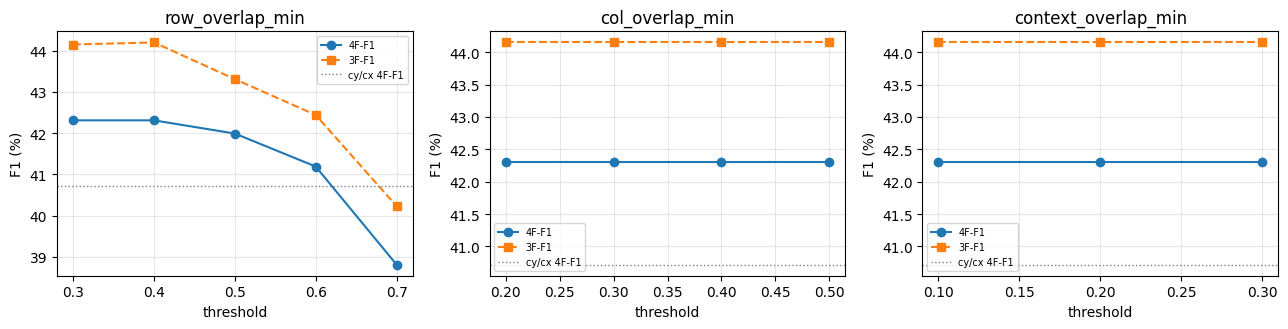

In [2]:
# =====================================================================
#  OVERLAP-MODE THRESHOLD SWEEP  —  Graph V2 + Association V2
#  Axes: row_overlap_min / col_overlap_min / context_overlap_min
#
#  SEARCH = COORDINATE DESCENT (forward greedy, with carry-forward):
#    1. sweep row_overlap_min      (col, ctx at defaults)      -> pick best_row
#    2. sweep col_overlap_min      (row=best_row, ctx default) -> pick best_col
#    3. sweep context_overlap_min  (row=best_row, col=best_col)-> pick best_ctx
#  Each axis is tuned with the previously-chosen winners held fixed, so the
#  endpoint (best_row, best_col, best_ctx) is the chain result — not a guess.
#
#  EVALUATOR: your deterministic path — LLMTupleEvaluator(use_llm=False).
#  No LLM, no Ollama. cy/cx is run as an in-harness reference (delta anchor).
#
#  Upstream (PaddleOCR -> corrector_v2 -> rule-based classifier -> enricher)
#  does NOT depend on the thresholds, so it runs ONCE per image and is cached.
#  Only Graph V2 + Association V2 + eval re-run per configuration. Re-running
#  this cell reuses the cache (delete ENRICHED_CACHE to rebuild).
#
#  REQUIRES: the UPDATED graph_constructor_v2.py (overlap mode) in src/graph/.
#  Run the notebook from the project root.
# =====================================================================

import os, sys, csv, time, io, tempfile, contextlib
from pathlib import Path

sys.path.insert(0, '.')

# ── Stage imports (mirror run_graph_v2_experiment.py wiring) ─────────
from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens      # canonical (C15-aware)
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens      # fallback (runner path)
from src.utils.token_enricher          import TokenEnricher
from src.matching.association_v2       import TupleAssociatorV2
from src.utils.paragraph_extractor     import extract_from_paragraph, should_use_paragraph_mode
from src.evaluation.llm_evaluator      import LLMTupleEvaluator       # deterministic w/ use_llm=False

# Graph constructor — assert overlap mode is present before anything else
from src.graph import graph_constructor_v2 as _gcv2
assert "row_overlap_min" in _gcv2.DEFAULT_CONFIG, (
    "graph_constructor_v2.py has no overlap mode — replace it with the "
    "updated file before running this sweep.")
GraphConstructorV2 = _gcv2.GraphConstructorV2

# Classifier (numeric-prefixed filename; normal import, importlib fallback)
try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    import importlib.util
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier


# ── Config ───────────────────────────────────────────────────────────
RAW_DIR         = "data/raw"
GT_CSV          = "test_set_normalized.csv"   # canonical GT: 866 tuples / 57 images
CLF_CONF_THRESH = 0.30                         # classifier conf threshold (graph-v2 runner value;
                                               #   OCR keeps ALL tokens — conf threshold = 0)
IMAGE_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# Overlap-mode defaults — starting point for axes not yet tuned
DEF_ROW, DEF_COL, DEF_CTX = 0.50, 0.30, 0.20

ROW_GRID = [0.30, 0.40, 0.50, 0.60, 0.70]
COL_GRID = [0.20, 0.30, 0.40, 0.50]
CTX_GRID = [0.10, 0.20, 0.30]


# ── Ground truth (normalized image_id so it matches predictions) ─────
def _norm_id(name: str) -> str:
    p = Path(name)
    return p.stem + p.suffix.lower()

# Preload GT rows; the evaluator's _load_gt() re-applies its own context
# (serving-size) handling. We only normalize the image_id here, because
# predictions use stem + suffix.lower() and the evaluator groups by the
# exact image_id string.
GT_PRELOADED = []
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        GT_PRELOADED.append({
            "image_id":     _norm_id(r["image_id"]),
            "nutrient":     (r.get("nutrient")     or "").strip(),
            "quantity":     (r.get("quantity")     or "").strip(),
            "unit":         (r.get("unit")         or "").strip(),
            "context":      (r.get("context")      or "").strip(),
            "serving_size": (r.get("serving_size") or "").strip(),
        })
GT_IDS = sorted({g["image_id"] for g in GT_PRELOADED})

def _find_image(img_id: str):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None


# ── Upstream cache (run once; OCR is the only expensive stage) ───────
if ("ENRICHED_CACHE" not in globals()
        or globals().get("_CACHE_KEY") != (CLF_CONF_THRESH,)):
    print("Building upstream cache "
          "(OCR -> corrector -> classifier -> enricher) ...", flush=True)
    _clf = SemanticClassifier(confidence_threshold=CLF_CONF_THRESH)
    _enr = TokenEnricher()
    ENRICHED_CACHE = {}                      # image_id -> {"enriched", "labeled"}
    _t0, _missing, _empty = time.time(), [], []
    for img_id in GT_IDS:
        fp = _find_image(img_id)
        if fp is None:
            _missing.append(img_id); continue
        try:
            toks      = run_ocr_on_image(str(fp))
            corr, _   = correct_tokens(toks, return_log=True)
            labeled   = _clf.classify_all(corr)
            enriched  = _enr.enrich(labeled)
            ENRICHED_CACHE[img_id] = {"enriched": enriched, "labeled": labeled}
            if not enriched:
                _empty.append(img_id)
        except Exception as e:
            print(f"  ERR  {img_id}: {e}")
    _CACHE_KEY = (CLF_CONF_THRESH,)
    print(f"  cached {len(ENRICHED_CACHE)}/{len(GT_IDS)} images "
          f"in {time.time()-_t0:.1f}s"
          + (f" | missing files: {_missing}" if _missing else "")
          + (f" | no enriched tokens: {_empty}" if _empty else ""))
else:
    print(f"Reusing cached upstream for {len(ENRICHED_CACHE)} images "
          f"(delete ENRICHED_CACHE to rebuild).")


# ── Deterministic evaluation via your LLMTupleEvaluator(use_llm=False) ─
# .run() prints a full report and writes 6 CSVs per call; for a sweep we
# suppress stdout and point output at a throwaway temp dir, reading only the
# returned metrics dict.
_EVAL_TMP = Path(tempfile.mkdtemp(prefix="overlap_sweep_eval_"))

def _evaluate(predictions) -> dict:
    ev  = LLMTupleEvaluator(gt_rows=GT_PRELOADED, use_llm=False)
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        m = ev.run(predictions, experiment="overlap_sweep", out_dir=_EVAL_TMP)
    return m


# ── Config runner (graph + association + paragraph fallback + eval) ──
_ASSOC = TupleAssociatorV2()

def run_config(row_mode, col_mode, ctx_mode,
               row_min=DEF_ROW, col_min=DEF_COL, ctx_min=DEF_CTX) -> dict:
    cfg = {
        "row_edge_mode":       row_mode,
        "col_edge_mode":       col_mode,
        "context_scope_mode":  ctx_mode,
        "row_overlap_min":     row_min,
        "col_overlap_min":     col_min,
        "context_overlap_min": ctx_min,
    }
    gc = GraphConstructorV2(cfg)
    preds, t0 = [], time.time()
    for img_id, cache in ENRICHED_CACHE.items():
        graph  = gc.build(cache["enriched"])
        tuples = _ASSOC.extract(graph, image_id=img_id)
        if should_use_paragraph_mode(cache["labeled"], len(tuples)):
            pt = extract_from_paragraph(cache["labeled"], img_id)
            if len(pt) > len(tuples):
                tuples = pt
        preds.extend(tuples)
    m = _evaluate(preds)
    return {
        "4f_f1": m.get("full_tuple_f1", 0.0),
        "4f_p":  m.get("full_tuple_precision", 0.0),
        "4f_r":  m.get("full_tuple_recall", 0.0),
        "3f_f1": m.get("full3f_f1", 0.0),
        "3f_p":  m.get("full3f_precision", 0.0),
        "3f_r":  m.get("full3f_recall", 0.0),
        "n_pred": len(preds),
        "secs":   round(time.time() - t0, 2),
    }


# ── Reference: current geometric cy/cx mode (same harness) ───────────
print(f"\n{'='*74}")
print("  REFERENCE — geometric cy/cx (current default mode)")
print(f"{'='*74}")
REF = run_config("cy", "cx", "cy")
print(f"  4F-F1={REF['4f_f1']*100:5.1f}%   3F-F1={REF['3f_f1']*100:5.1f}%   "
      f"P={REF['4f_p']*100:4.1f}  R={REF['4f_r']*100:4.1f}   "
      f"pred={REF['n_pred']:>4}   ({REF['secs']}s)")


# ── Coordinate-descent sweep (winners carried forward) ───────────────
_AX_NAME = {"row_min": "row", "col_min": "col", "ctx_min": "ctx"}

def _sweep(label, kw_key, grid, fixed):
    """Sweep one axis with the other two HELD at `fixed`; return (results, best_value).
    `fixed` carries the winners chosen by earlier axes (coordinate descent)."""
    held = " ".join(f"{_AX_NAME[k]}={fixed[k]}"
                    for k in ("row_min", "col_min", "ctx_min") if k != kw_key)
    print(f"\n{'='*74}")
    print(f"  AXIS — {label}   (held: {held})")
    print(f"{'='*74}")
    results = []
    for v in grid:
        kw = dict(fixed); kw[kw_key] = v
        m = run_config("overlap", "overlap", "overlap", **kw)
        results.append((v, m))
        d = (m["4f_f1"] - REF["4f_f1"]) * 100
        print(f"  {label}={v:<5} 4F-F1={m['4f_f1']*100:5.1f}%  "
              f"3F-F1={m['3f_f1']*100:5.1f}%  "
              f"P={m['4f_p']*100:4.1f} R={m['4f_r']*100:4.1f}  "
              f"pred={m['n_pred']:>4}  Δvsref={d:+5.1f}pp  ({m['secs']}s)")
    best_v = max(results, key=lambda r: r[1]["4f_f1"])[0]
    best_f = max(r[1]["4f_f1"] for r in results)
    print(f"  -> best {label} = {best_v}  @ 4F-F1={best_f*100:.1f}%   (carried forward)")
    return results, best_v

# 1) row first, col/ctx at defaults
row_results, best_row = _sweep(
    "row_overlap_min", "row_min", ROW_GRID,
    {"row_min": DEF_ROW, "col_min": DEF_COL, "ctx_min": DEF_CTX})

# 2) col with row pinned at its winner
col_results, best_col = _sweep(
    "col_overlap_min", "col_min", COL_GRID,
    {"row_min": best_row, "col_min": DEF_COL, "ctx_min": DEF_CTX})

# 3) context with row+col pinned at their winners
ctx_results, best_ctx = _sweep(
    "context_overlap_min", "ctx_min", CTX_GRID,
    {"row_min": best_row, "col_min": best_col, "ctx_min": DEF_CTX})


# ── Coordinate-descent endpoint ──────────────────────────────────────
print(f"\n{'='*74}")
print(f"  ENDPOINT (coordinate descent) — row={best_row} col={best_col} ctx={best_ctx}")
print(f"{'='*74}")
COMBO = run_config("overlap", "overlap", "overlap",
                   row_min=best_row, col_min=best_col, ctx_min=best_ctx)
print(f"  overlap  4F-F1={COMBO['4f_f1']*100:5.1f}%  3F-F1={COMBO['3f_f1']*100:5.1f}%  "
      f"pred={COMBO['n_pred']}")
print(f"  cy/cx    4F-F1={REF['4f_f1']*100:5.1f}%  "
      f"(Δ = {(COMBO['4f_f1']-REF['4f_f1'])*100:+.1f} pp)")
print("  NOTE: single-pass coordinate descent. For full rigor, re-sweep row at "
      "(best_col, best_ctx) until stable — here col/ctx are inert, so already stable.")


# ── Plot: 4F/3F-F1 vs threshold per axis (optional) ──────────────────
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for ax, (name, res) in zip(axes, [("row_overlap_min", row_results),
                                       ("col_overlap_min", col_results),
                                       ("context_overlap_min", ctx_results)]):
        xs = [v for v, _ in res]
        ax.plot(xs, [m["4f_f1"]*100 for _, m in res], "o-", label="4F-F1")
        ax.plot(xs, [m["3f_f1"]*100 for _, m in res], "s--", label="3F-F1")
        ax.axhline(REF["4f_f1"]*100, color="gray", ls=":", lw=1, label="cy/cx 4F-F1")
        ax.set_title(name); ax.set_xlabel("threshold"); ax.set_ylabel("F1 (%)")
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"[plot skipped] {e}")

AssertionError: graph_constructor_v2.py has no overlap_denom — replace it with the updated file before running this sweep.

[denom sweep] starting — importing modules + checking graph constructor ...
[denom sweep] graph module OK — overlap_denom default = 'min'
[denom sweep] reusing cached upstream for 57 images (no re-OCR).

  REFERENCES
  cy/cx (centroid)        4F-F1= 40.7%  3F-F1= 43.0%  P=39.7 R=41.8  pred=912
  overlap/min@0.3 (incumbent) 4F-F1= 42.3%  3F-F1= 44.1%  P=42.2 R=42.4  pred=869

  DENOMINATOR = min   (row threshold sweep; col/ctx held 0.2/0.1)
  row=0.1   4F-F1= 41.0%  3F-F1= 43.3%  P=39.0 R=43.3  pred= 962  Δcy/cx= +0.3  Δinc= -1.3  (0.32s)
  row=0.15  4F-F1= 41.3%  3F-F1= 43.4%  P=39.7 R=43.1  pred= 939  Δcy/cx= +0.6  Δinc= -1.0  (0.36s)
  row=0.2   4F-F1= 41.6%  3F-F1= 43.4%  P=40.5 R=42.7  pred= 913  Δcy/cx= +0.9  Δinc= -0.7  (0.36s)
  row=0.25  4F-F1= 42.0%  3F-F1= 43.8%  P=41.4 R=42.6  pred= 891  Δcy/cx= +1.3  Δinc= -0.3  (0.31s)
  row=0.3   4F-F1= 42.3%  3F-F1= 44.1%  P=42.2 R=42.4  pred= 869  Δcy/cx= +1.6  Δinc= +0.0  (0.3s)
  row=0.35  4F-F1= 42.3%  3F-F1= 44.1%  P=42.6 R=41.9  pr

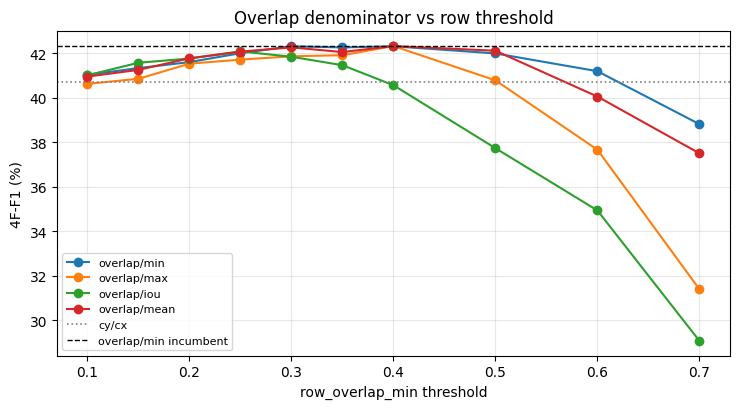

[denom sweep] done.


In [8]:
# =====================================================================
#  OVERLAP DENOMINATOR SWEEP  —  Graph V2 + Association V2   (hardened I/O)
#  Question: does a different overlap denominator on the ROW axis beat the
#  adopted overlap/min (overlap / shorter box)?
#
#  Denominators (config key `overlap_denom`):
#    min  : overlap / shorter   (adopted; most permissive)
#    max  : overlap / longer    (most strict; penalises size mismatch)
#    iou  : overlap / union     (1-D IoU; intermediate)
#    mean : overlap / mean-len
#
#  Each denominator gets its OWN row-threshold sweep (the denominator rescales
#  the threshold). col/ctx held at overlap defaults (inert). Deterministic
#  evaluator LLMTupleEvaluator(use_llm=False). References: cy/cx + overlap/min@0.30.
#
#  I/O NOTES:
#   - prints flush immediately (so output streams in VS Code / Jupyter);
#   - importlib.reload picks up an edited graph_constructor_v2.py WITHOUT a
#     kernel restart, so ENRICHED_CACHE survives and there is no 197s re-OCR.
#  Run the notebook from the project root.
# =====================================================================

import os, sys, csv, time, io, tempfile, contextlib, importlib, importlib.util
from pathlib import Path
print("[denom sweep] starting — importing modules + checking graph constructor ...", flush=True)

sys.path.insert(0, '.')

def log(*args, **kw):
    """print that always flushes (live output during long cells)."""
    kw["flush"] = True
    print(*args, **kw)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens
from src.utils.token_enricher          import TokenEnricher
from src.matching.association_v2       import TupleAssociatorV2
from src.utils.paragraph_extractor     import extract_from_paragraph, should_use_paragraph_mode
from src.evaluation.llm_evaluator      import LLMTupleEvaluator

# Reload the graph module so an edited graph_constructor_v2.py is picked up even
# if it was already imported earlier this session (avoids a kernel restart).
from src.graph import graph_constructor_v2 as _gcv2
importlib.reload(_gcv2)
GraphConstructorV2 = _gcv2.GraphConstructorV2
if "overlap_denom" not in _gcv2.DEFAULT_CONFIG:
    raise RuntimeError(
        "graph_constructor_v2.py has no `overlap_denom`. Replace it with the "
        "updated file (the one with min/max/iou/mean support), then re-run.")
log(f"[denom sweep] graph module OK — overlap_denom default = "
    f"{_gcv2.DEFAULT_CONFIG['overlap_denom']!r}")

try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier


# ── Config ───────────────────────────────────────────────────────────
RAW_DIR         = "data/raw"
GT_CSV          = "test_set_normalized.csv"
CLF_CONF_THRESH = 0.30
IMAGE_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

DENOMS    = ["min", "max", "iou", "mean"]
ROW_GRID  = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]
DEF_COL, DEF_CTX = 0.20, 0.10
INCUMBENT_DENOM, INCUMBENT_ROW = "min", 0.30


# ── Ground truth (normalized image_id) ───────────────────────────────
def _norm_id(name):
    p = Path(name)
    return p.stem + p.suffix.lower()

GT_PRELOADED = []
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        GT_PRELOADED.append({
            "image_id":     _norm_id(r["image_id"]),
            "nutrient":     (r.get("nutrient")     or "").strip(),
            "quantity":     (r.get("quantity")     or "").strip(),
            "unit":         (r.get("unit")         or "").strip(),
            "context":      (r.get("context")      or "").strip(),
            "serving_size": (r.get("serving_size") or "").strip(),
        })
GT_IDS = sorted({g["image_id"] for g in GT_PRELOADED})

def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None


# ── Upstream cache (shared with the threshold sweep) ─────────────────
if ("ENRICHED_CACHE" not in globals()
        or globals().get("_CACHE_KEY") != (CLF_CONF_THRESH,)):
    log("[denom sweep] building upstream cache "
        "(OCR -> corrector -> classifier -> enricher); this is the slow part "
        "(~3 min on first run, once per kernel) ...")
    _clf = SemanticClassifier(confidence_threshold=CLF_CONF_THRESH)
    _enr = TokenEnricher()
    ENRICHED_CACHE = {}
    _t0, _missing = time.time(), []
    for _i, img_id in enumerate(GT_IDS, 1):
        fp = _find_image(img_id)
        if fp is None:
            _missing.append(img_id); continue
        try:
            toks    = run_ocr_on_image(str(fp))
            corr, _ = correct_tokens(toks, return_log=True)
            lab     = _clf.classify_all(corr)
            enr     = _enr.enrich(lab)
            ENRICHED_CACHE[img_id] = {"enriched": enr, "labeled": lab}
        except Exception as e:
            log(f"  ERR  {img_id}: {e}")
        if _i % 10 == 0:
            log(f"    ... {_i}/{len(GT_IDS)} images ({time.time()-_t0:.0f}s)")
    _CACHE_KEY = (CLF_CONF_THRESH,)
    log(f"[denom sweep] cached {len(ENRICHED_CACHE)}/{len(GT_IDS)} images "
        f"in {time.time()-_t0:.1f}s"
        + (f" | missing: {_missing}" if _missing else ""))
else:
    log(f"[denom sweep] reusing cached upstream for {len(ENRICHED_CACHE)} images "
        "(no re-OCR).")


# ── Deterministic evaluation (your evaluator) ────────────────────────
_EVAL_TMP = Path(tempfile.mkdtemp(prefix="denom_sweep_eval_"))

def _evaluate(predictions):
    ev  = LLMTupleEvaluator(gt_rows=GT_PRELOADED, use_llm=False)
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        m = ev.run(predictions, experiment="denom_sweep", out_dir=_EVAL_TMP)
    return m


# ── Config runner ────────────────────────────────────────────────────
_ASSOC = TupleAssociatorV2()

def run_config(row_mode, col_mode, ctx_mode,
               row_min=INCUMBENT_ROW, col_min=DEF_COL, ctx_min=DEF_CTX,
               denom="min"):
    cfg = {
        "row_edge_mode":       row_mode,
        "col_edge_mode":       col_mode,
        "context_scope_mode":  ctx_mode,
        "row_overlap_min":     row_min,
        "col_overlap_min":     col_min,
        "context_overlap_min": ctx_min,
        "overlap_denom":       denom,
    }
    gc = GraphConstructorV2(cfg)
    preds, t0 = [], time.time()
    for img_id, cache in ENRICHED_CACHE.items():
        graph  = gc.build(cache["enriched"])
        tuples = _ASSOC.extract(graph, image_id=img_id)
        if should_use_paragraph_mode(cache["labeled"], len(tuples)):
            pt = extract_from_paragraph(cache["labeled"], img_id)
            if len(pt) > len(tuples):
                tuples = pt
        preds.extend(tuples)
    m = _evaluate(preds)
    return {"4f_f1": m.get("full_tuple_f1", 0.0),
            "4f_p":  m.get("full_tuple_precision", 0.0),
            "4f_r":  m.get("full_tuple_recall", 0.0),
            "3f_f1": m.get("full3f_f1", 0.0),
            "n_pred": len(preds), "secs": round(time.time()-t0, 2)}


# ── References ───────────────────────────────────────────────────────
log(f"\n{'='*78}")
log("  REFERENCES")
log(f"{'='*78}")
REF = run_config("cy", "cx", "cy")
log(f"  cy/cx (centroid)        4F-F1={REF['4f_f1']*100:5.1f}%  3F-F1={REF['3f_f1']*100:5.1f}%  "
    f"P={REF['4f_p']*100:4.1f} R={REF['4f_r']*100:4.1f}  pred={REF['n_pred']}")
INC = run_config("overlap", "overlap", "overlap",
                 row_min=INCUMBENT_ROW, denom=INCUMBENT_DENOM)
log(f"  overlap/{INCUMBENT_DENOM}@{INCUMBENT_ROW} (incumbent) "
    f"4F-F1={INC['4f_f1']*100:5.1f}%  3F-F1={INC['3f_f1']*100:5.1f}%  "
    f"P={INC['4f_p']*100:4.1f} R={INC['4f_r']*100:4.1f}  pred={INC['n_pred']}")


# ── Per-denominator row-threshold sweep ──────────────────────────────
all_results = {}
best = {}

for denom in DENOMS:
    log(f"\n{'='*78}")
    log(f"  DENOMINATOR = {denom}   (row threshold sweep; col/ctx held {DEF_COL}/{DEF_CTX})")
    log(f"{'='*78}")
    rows = []
    for v in ROW_GRID:
        m = run_config("overlap", "overlap", "overlap", row_min=v, denom=denom)
        rows.append((v, m))
        dref = (m["4f_f1"] - REF["4f_f1"]) * 100
        dinc = (m["4f_f1"] - INC["4f_f1"]) * 100
        log(f"  row={v:<5} 4F-F1={m['4f_f1']*100:5.1f}%  3F-F1={m['3f_f1']*100:5.1f}%  "
            f"P={m['4f_p']*100:4.1f} R={m['4f_r']*100:4.1f}  pred={m['n_pred']:>4}  "
            f"Δcy/cx={dref:+5.1f}  Δinc={dinc:+5.1f}  ({m['secs']}s)")
    bthr, bm = max(rows, key=lambda r: r[1]["4f_f1"])
    all_results[denom] = rows
    best[denom] = (bthr, bm)
    log(f"  -> best {denom}: row={bthr} @ 4F-F1={bm['4f_f1']*100:.1f}%")


# ── Summary ──────────────────────────────────────────────────────────
log(f"\n{'='*78}")
log("  SUMMARY — best per denominator")
log(f"{'='*78}")
log(f"  {'denom':<6} {'row*':>5}  {'4F-F1':>6}  {'3F-F1':>6}  {'P':>5} {'R':>5}  "
    f"{'pred':>5}  {'Δcy/cx':>7}  {'Δinc':>6}")
log(f"  {'-'*70}")
log(f"  {'cy/cx':<6} {'-':>5}  {REF['4f_f1']*100:5.1f}%  {REF['3f_f1']*100:5.1f}%  "
    f"{REF['4f_p']*100:4.1f} {REF['4f_r']*100:4.1f}  {REF['n_pred']:>5}  {'-':>7}  {'-':>6}")
for denom in DENOMS:
    bthr, bm = best[denom]
    dref = (bm["4f_f1"] - REF["4f_f1"]) * 100
    dinc = (bm["4f_f1"] - INC["4f_f1"]) * 100
    tag = "  <- incumbent" if (denom == INCUMBENT_DENOM) else ""
    log(f"  {denom:<6} {bthr:>5}  {bm['4f_f1']*100:5.1f}%  {bm['3f_f1']*100:5.1f}%  "
        f"{bm['4f_p']*100:4.1f} {bm['4f_r']*100:4.1f}  {bm['n_pred']:>5}  "
        f"{dref:+6.1f}p  {dinc:+5.1f}p{tag}")

win_denom = max(DENOMS, key=lambda d: best[d][1]["4f_f1"])
win_thr, win_m = best[win_denom]
verdict = ("ties / does not beat" if abs(win_m["4f_f1"] - INC["4f_f1"]) < 1e-9
           else ("BEATS" if win_m["4f_f1"] > INC["4f_f1"] else "loses to"))
log(f"\n  Best overall: overlap/{win_denom}@{win_thr} = {win_m['4f_f1']*100:.1f}% 4F-F1 "
    f"-> {verdict} the incumbent overlap/{INCUMBENT_DENOM}@{INCUMBENT_ROW} "
    f"({INC['4f_f1']*100:.1f}%).")


# ── Plot ─────────────────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7.5, 4.2))
    for denom in DENOMS:
        xs = [v for v, _ in all_results[denom]]
        ys = [m["4f_f1"]*100 for _, m in all_results[denom]]
        plt.plot(xs, ys, "o-", label=f"overlap/{denom}")
    plt.axhline(REF["4f_f1"]*100, color="gray", ls=":", lw=1.2, label="cy/cx")
    plt.axhline(INC["4f_f1"]*100, color="black", ls="--", lw=1.0, label="overlap/min incumbent")
    plt.xlabel("row_overlap_min threshold"); plt.ylabel("4F-F1 (%)")
    plt.title("Overlap denominator vs row threshold")
    plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()
except Exception as e:
    log(f"[plot skipped] {e}")

log("[denom sweep] done.")

In [9]:
# =====================================================================
#  OVERLAP_MNN SWEEP  —  competitive (mutual-nearest) ROW edges
#  Idea 1 of 2. row_edge_mode="overlap_mnn": build overlap row candidates,
#  then keep an edge only if its overlap weight is within mnn_tol of EACH
#  endpoint's best row edge to a node of the other's label (per-label
#  competition -> keeps same-row multiples, drops adjacent-row leakage).
#
#  MNN needs adjacent-row candidates to compete away, so the base
#  row_overlap_min is swept LOOSE; mnn_tol does the pruning. 2-D grid:
#      base row_overlap_min  x  mnn_tol
#  References: cy/cx and the incumbent overlap/min@0.30 (42.3%).
#  Sanity: overlap_mnn(base=0.30, tol=1.0) == incumbent (no pruning).
#
#  Deterministic LLMTupleEvaluator(use_llm=False). flushes live; reloads the
#  graph module so an edited graph_constructor_v2.py is picked up without a
#  kernel restart (keeps ENRICHED_CACHE; no re-OCR). Run from project root.
#  REQUIRES the graph_constructor_v2.py with overlap_mnn + mnn_tol support.
# =====================================================================

import os, sys, csv, time, io, tempfile, contextlib, importlib, importlib.util
from pathlib import Path
print("[mnn sweep] starting — importing + checking graph constructor ...", flush=True)

sys.path.insert(0, '.')

def log(*args, **kw):
    kw["flush"] = True
    print(*args, **kw)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens
from src.utils.token_enricher          import TokenEnricher
from src.matching.association_v2       import TupleAssociatorV2
from src.utils.paragraph_extractor     import extract_from_paragraph, should_use_paragraph_mode
from src.evaluation.llm_evaluator      import LLMTupleEvaluator

from src.graph import graph_constructor_v2 as _gcv2
importlib.reload(_gcv2)
GraphConstructorV2 = _gcv2.GraphConstructorV2
if "mnn_tol" not in _gcv2.DEFAULT_CONFIG or not hasattr(_gcv2, "_prune_row_mnn"):
    raise RuntimeError(
        "graph_constructor_v2.py has no overlap_mnn support (mnn_tol / "
        "_prune_row_mnn missing). Replace it with the updated file, then re-run.")
log("[mnn sweep] graph module OK — overlap_mnn available.")

try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier


# ── Config ───────────────────────────────────────────────────────────
RAW_DIR         = "data/raw"
GT_CSV          = "test_set_normalized.csv"
CLF_CONF_THRESH = 0.30
IMAGE_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

BASE_GRID = [0.05, 0.10, 0.15, 0.20, 0.30]   # loose row_overlap_min (candidates)
TOL_GRID  = [0.05, 0.10, 0.15, 0.20, 0.30]   # mnn_tol (pruning strength)
INC_DENOM, INC_ROW = "min", 0.30             # incumbent overlap/min@0.30


# ── Ground truth (normalized image_id) ───────────────────────────────
def _norm_id(name):
    p = Path(name)
    return p.stem + p.suffix.lower()

GT_PRELOADED = []
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        GT_PRELOADED.append({
            "image_id":     _norm_id(r["image_id"]),
            "nutrient":     (r.get("nutrient")     or "").strip(),
            "quantity":     (r.get("quantity")     or "").strip(),
            "unit":         (r.get("unit")         or "").strip(),
            "context":      (r.get("context")      or "").strip(),
            "serving_size": (r.get("serving_size") or "").strip(),
        })
GT_IDS = sorted({g["image_id"] for g in GT_PRELOADED})

def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None


# ── Upstream cache (shared with other sweeps) ────────────────────────
if ("ENRICHED_CACHE" not in globals()
        or globals().get("_CACHE_KEY") != (CLF_CONF_THRESH,)):
    log("[mnn sweep] building upstream cache (OCR -> corrector -> classifier -> "
        "enricher); slow part (~3 min, once per kernel) ...")
    _clf = SemanticClassifier(confidence_threshold=CLF_CONF_THRESH)
    _enr = TokenEnricher()
    ENRICHED_CACHE = {}
    _t0, _missing = time.time(), []
    for _i, img_id in enumerate(GT_IDS, 1):
        fp = _find_image(img_id)
        if fp is None:
            _missing.append(img_id); continue
        try:
            toks    = run_ocr_on_image(str(fp))
            corr, _ = correct_tokens(toks, return_log=True)
            lab     = _clf.classify_all(corr)
            enr     = _enr.enrich(lab)
            ENRICHED_CACHE[img_id] = {"enriched": enr, "labeled": lab}
        except Exception as e:
            log(f"  ERR  {img_id}: {e}")
        if _i % 10 == 0:
            log(f"    ... {_i}/{len(GT_IDS)} images ({time.time()-_t0:.0f}s)")
    _CACHE_KEY = (CLF_CONF_THRESH,)
    log(f"[mnn sweep] cached {len(ENRICHED_CACHE)}/{len(GT_IDS)} images "
        f"in {time.time()-_t0:.1f}s"
        + (f" | missing: {_missing}" if _missing else ""))
else:
    log(f"[mnn sweep] reusing cached upstream for {len(ENRICHED_CACHE)} images "
        "(no re-OCR).")


# ── Deterministic evaluation ─────────────────────────────────────────
_EVAL_TMP = Path(tempfile.mkdtemp(prefix="mnn_sweep_eval_"))

def _evaluate(predictions):
    ev  = LLMTupleEvaluator(gt_rows=GT_PRELOADED, use_llm=False)
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        m = ev.run(predictions, experiment="mnn_sweep", out_dir=_EVAL_TMP)
    return m


# ── Config runner ────────────────────────────────────────────────────
_ASSOC = TupleAssociatorV2()

def run_config(row_mode, col_mode, ctx_mode,
               row_min=INC_ROW, col_min=0.20, ctx_min=0.10,
               denom="min", mnn_tol=0.10):
    cfg = {
        "row_edge_mode":       row_mode,
        "col_edge_mode":       col_mode,
        "context_scope_mode":  ctx_mode,
        "row_overlap_min":     row_min,
        "col_overlap_min":     col_min,
        "context_overlap_min": ctx_min,
        "overlap_denom":       denom,
        "mnn_tol":             mnn_tol,
    }
    gc = GraphConstructorV2(cfg)
    preds = []
    for img_id, cache in ENRICHED_CACHE.items():
        graph  = gc.build(cache["enriched"])
        tuples = _ASSOC.extract(graph, image_id=img_id)
        if should_use_paragraph_mode(cache["labeled"], len(tuples)):
            pt = extract_from_paragraph(cache["labeled"], img_id)
            if len(pt) > len(tuples):
                tuples = pt
        preds.extend(tuples)
    m = _evaluate(preds)
    return {"4f_f1": m.get("full_tuple_f1", 0.0),
            "4f_p":  m.get("full_tuple_precision", 0.0),
            "4f_r":  m.get("full_tuple_recall", 0.0),
            "3f_f1": m.get("full3f_f1", 0.0),
            "n_pred": len(preds)}


# ── References + sanity ──────────────────────────────────────────────
log(f"\n{'='*78}")
log("  REFERENCES")
log(f"{'='*78}")
REF = run_config("cy", "cx", "cy")
log(f"  cy/cx (centroid)            4F-F1={REF['4f_f1']*100:5.1f}%  3F-F1={REF['3f_f1']*100:5.1f}%  "
    f"P={REF['4f_p']*100:4.1f} R={REF['4f_r']*100:4.1f}  pred={REF['n_pred']}")
INC = run_config("overlap", "overlap", "overlap", row_min=INC_ROW, denom=INC_DENOM)
log(f"  overlap/min@{INC_ROW} (incumbent)  4F-F1={INC['4f_f1']*100:5.1f}%  3F-F1={INC['3f_f1']*100:5.1f}%  "
    f"P={INC['4f_p']*100:4.1f} R={INC['4f_r']*100:4.1f}  pred={INC['n_pred']}")
SAN = run_config("overlap_mnn", "overlap", "overlap", row_min=INC_ROW, mnn_tol=1.0)
_ok = "OK" if abs(SAN['4f_f1'] - INC['4f_f1']) < 1e-9 else "MISMATCH"
log(f"  sanity overlap_mnn@{INC_ROW},tol=1.0 (no prune)  4F-F1={SAN['4f_f1']*100:5.1f}%  "
    f"[{_ok} vs incumbent]")


# ── 2-D sweep: base row threshold x mnn_tol ──────────────────────────
log(f"\n{'='*78}")
log("  overlap_mnn 2-D SWEEP   rows = base row_overlap_min, cols = mnn_tol")
log(f"{'='*78}")
grid = {}    # (base, tol) -> metrics
best = None  # (4f_f1, base, tol, metrics)

# header
log("   base \\ tol  " + "".join(f"{t:>7}" for t in TOL_GRID))
for base in BASE_GRID:
    cells = []
    for tol in TOL_GRID:
        m = run_config("overlap_mnn", "overlap", "overlap",
                       row_min=base, denom="min", mnn_tol=tol)
        grid[(base, tol)] = m
        cells.append(m["4f_f1"]*100)
        if best is None or m["4f_f1"] > best[0]:
            best = (m["4f_f1"], base, tol, m)
    log(f"   {base:<10}" + "".join(f"{c:>6.1f} " for c in cells))

log(f"\n  (cells = 4F-F1 %.  incumbent overlap/min@0.30 = {INC['4f_f1']*100:.1f}%, "
    f"cy/cx = {REF['4f_f1']*100:.1f}%)")


# ── Best cell + verdict ──────────────────────────────────────────────
bf, bbase, btol, bm = best
dinc = (bf - INC["4f_f1"]) * 100
dref = (bf - REF["4f_f1"]) * 100
verdict = ("ties / does not beat" if abs(bf - INC["4f_f1"]) < 1e-9
           else ("BEATS" if bf > INC["4f_f1"] else "loses to"))
log(f"\n{'='*78}")
log("  BEST overlap_mnn CELL")
log(f"{'='*78}")
log(f"  base row_overlap_min = {bbase}   mnn_tol = {btol}")
log(f"  4F-F1 = {bm['4f_f1']*100:.1f}%   3F-F1 = {bm['3f_f1']*100:.1f}%   "
    f"P = {bm['4f_p']*100:.1f}   R = {bm['4f_r']*100:.1f}   pred = {bm['n_pred']}")
log(f"  Δ vs incumbent = {dinc:+.1f}p     Δ vs cy/cx = {dref:+.1f}p")
log(f"\n  Verdict: best overlap_mnn ({bf*100:.1f}%) {verdict} the incumbent "
    f"overlap/min@0.30 ({INC['4f_f1']*100:.1f}%).")
log("\n  Reminder: MNN targets WRONG-ROW binding. If this ties the incumbent, the "
    "remaining dense-table errors (118/119) are WRONG-COLUMN — that is idea 2.")
log("[mnn sweep] done.")

[mnn sweep] starting — importing + checking graph constructor ...
[mnn sweep] graph module OK — overlap_mnn available.
[mnn sweep] reusing cached upstream for 57 images (no re-OCR).

  REFERENCES
  cy/cx (centroid)            4F-F1= 40.7%  3F-F1= 43.0%  P=39.7 R=41.8  pred=912
  overlap/min@0.3 (incumbent)  4F-F1= 42.3%  3F-F1= 44.1%  P=42.2 R=42.4  pred=869
  sanity overlap_mnn@0.3,tol=1.0 (no prune)  4F-F1= 42.3%  [OK vs incumbent]

  overlap_mnn 2-D SWEEP   rows = base row_overlap_min, cols = mnn_tol
   base \ tol     0.05    0.1   0.15    0.2    0.3
   0.05        37.9   39.0   40.4   40.7   42.3 
   0.1         37.9   39.0   40.4   40.7   42.3 
   0.15        37.9   39.0   40.4   40.7   42.3 
   0.2         37.9   39.0   40.4   40.6   42.2 
   0.3         37.6   38.8   40.2   40.4   42.2 

  (cells = 4F-F1 %.  incumbent overlap/min@0.30 = 42.3%, cy/cx = 40.7%)

  BEST overlap_mnn CELL
  base row_overlap_min = 0.05   mnn_tol = 0.3
  4F-F1 = 42.3%   3F-F1 = 43.5%   P = 45.0   R = 39

In [10]:
# =====================================================================
#  DENSE-TABLE COLUMN DIAGNOSTIC  —  118 / 119 (per_100g | per_serving)
#  Goal: SEE the actual failure before building the header-binding edge.
#  Dumps, per target image:
#    - NUTRIENT nodes (cy, row, rank)
#    - QUANTITY nodes (token, cx, cy, x-extent, column_id, stream, ctx_id, rank)
#    - CONTEXT nodes  (token/norm, cx, x-extent, column_id)
#    - what the ASSOCIATOR currently selects per nutrient (cy-closest-3, cx-sort)
#    - predicted tuples vs GT
#  Read-only: uses the current default graph config + association. No edits.
#  Reuses ENRICHED_CACHE if present; else OCRs just the targets.
#  Run from project root.
# =====================================================================

import os, sys, csv, importlib, importlib.util
from pathlib import Path
print("[diag] starting ...", flush=True)
sys.path.insert(0, '.')

def log(*a, **k): k["flush"] = True; print(*a, **k)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens
from src.utils.token_enricher          import TokenEnricher
from src.matching.association_v2       import TupleAssociatorV2
from src.graph import graph_constructor_v2 as _gcv2
importlib.reload(_gcv2)
GraphConstructorV2 = _gcv2.GraphConstructorV2
try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier

RAW_DIR    = "data/raw"
GT_CSV     = "test_set_normalized.csv"
TARGETS    = ["118.jpeg", "119.jpeg"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

def _norm_id(name):
    p = Path(name); return p.stem + p.suffix.lower()

def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None

# GT for targets
GT = {t: [] for t in TARGETS}
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        iid = _norm_id(r["image_id"])
        if iid in GT:
            GT[iid].append(r)

# upstream: reuse cache or OCR just the targets
_clf = None; _enr = TokenEnricher()
def _enrich_one(img_id):
    global _clf
    if "ENRICHED_CACHE" in globals() and img_id in globals()["ENRICHED_CACHE"]:
        return globals()["ENRICHED_CACHE"][img_id]
    if _clf is None:
        _clf = SemanticClassifier(confidence_threshold=0.30)
    fp = _find_image(img_id)
    toks    = run_ocr_on_image(str(fp))
    corr, _ = correct_tokens(toks, return_log=True)
    lab     = _clf.classify_all(corr)
    enr     = _enr.enrich(lab)
    return {"enriched": enr, "labeled": lab}

GC    = GraphConstructorV2()           # current default config (overlap)
ASSOC = TupleAssociatorV2()

def _f(n, k, d=0): 
    v = n.get(k, d); 
    return v if isinstance(v, (int, float)) else d

for img_id in TARGETS:
    log(f"\n{'#'*78}\n#  {img_id}\n{'#'*78}")
    cache = _enrich_one(img_id)
    graph = GC.build(cache["enriched"])
    nodes = graph["nodes"]
    node_map = {n["id"]: n for n in nodes}

    nutrients = [n for n in nodes if n.get("label") == "NUTRIENT"]
    quants    = [n for n in nodes if n.get("label") == "QUANTITY"]
    contexts  = [n for n in nodes if n.get("label") == "CONTEXT"]

    # CONTEXT nodes (the column headers)
    log(f"\n--- CONTEXT nodes ({len(contexts)}) : the column headers ---")
    log(f"  {'token':<22} {'norm':<14} {'cx':>6} {'x1':>6} {'x2':>6} {'col_id':>6}")
    for c in sorted(contexts, key=lambda n: _f(n, 'cx')):
        log(f"  {str(c.get('token',''))[:21]:<22} {str(c.get('norm',''))[:13]:<14} "
            f"{_f(c,'cx'):>6.0f} {_f(c,'x1'):>6.0f} {_f(c,'x2'):>6.0f} "
            f"{c.get('column_id',-1):>6}")

    # QUANTITY nodes (do they separate into 2 cx clusters?)
    log(f"\n--- QUANTITY nodes ({len(quants)}) sorted by cy then cx ---")
    log(f"  {'token':<10} {'cx':>6} {'cy':>6} {'x1':>6} {'x2':>6} "
        f"{'col_id':>6} {'stream':>6} {'ctx_id':<14} {'qrank':>5}")
    for q in sorted(quants, key=lambda n: (_f(n,'cy'), _f(n,'cx'))):
        log(f"  {str(q.get('token',''))[:9]:<10} {_f(q,'cx'):>6.0f} {_f(q,'cy'):>6.0f} "
            f"{_f(q,'x1'):>6.0f} {_f(q,'x2'):>6.0f} {q.get('column_id',-1):>6} "
            f"{q.get('dosage_stream_id',-1):>6} "
            f"{str(q.get('column_context_id',''))[:13]:<14} "
            f"{q.get('qty_rank_in_column',-1):>5}")

    # What the associator SEES + SELECTS per nutrient
    row_q = {}
    for e in graph["edges"]:
        if e["type"] == "ROW_COMPAT":
            dst = node_map.get(e["dst"])
            if dst and dst.get("label") == "QUANTITY":
                row_q.setdefault(e["src"], []).append(dst)
    log(f"\n--- per-NUTRIENT: ROW_COMPAT quantities -> current selection ---")
    log("  (selection = sort by |cy-nut|, keep 3, sort cx left->right)")
    for nut in sorted(nutrients, key=lambda n: _f(n, 'cy')):
        nid = nut["id"]; ncy = _f(nut, "cy")
        cand = row_q.get(nid, [])
        cand_sorted = sorted(cand, key=lambda n: abs(_f(n,'cy') - ncy))[:3]
        sel = sorted(cand_sorted, key=lambda n: _f(n,'cx'))
        cand_str = " ".join(f"{q.get('token','')}@{_f(q,'cx'):.0f}" for q in
                            sorted(cand, key=lambda n: _f(n,'cx')))
        sel_str  = " ".join(f"{q.get('token','')}@cx{_f(q,'cx'):.0f}" for q in sel)
        log(f"  {str(nut.get('token',''))[:18]:<19} cy={ncy:>5.0f} "
            f"row_cands=[{cand_str}]")
        log(f"  {'':19} -> SELECT [{sel_str}]")

    # Predicted tuples vs GT
    preds = ASSOC.extract(graph, image_id=img_id)
    log(f"\n--- PREDICTED tuples ({len(preds)}) ---")
    log(f"  {'nutrient':<18} {'qty':<8} {'unit':<6} {'context':<14}")
    for t in preds:
        log(f"  {str(t.get('nutrient',''))[:17]:<18} {str(t.get('quantity',''))[:7]:<8} "
            f"{str(t.get('unit',''))[:5]:<6} {str(t.get('context',''))[:13]:<14}")

    log(f"\n--- GROUND TRUTH ({len(GT[img_id])}) ---")
    log(f"  {'nutrient':<18} {'qty':<8} {'unit':<6} {'context':<14}")
    for r in GT[img_id]:
        log(f"  {str(r.get('nutrient',''))[:17]:<18} {str(r.get('quantity',''))[:7]:<8} "
            f"{str(r.get('unit',''))[:5]:<6} {str(r.get('context',''))[:13]:<14}")

log("\n[diag] done.")

[diag] starting ...

##############################################################################
#  118.jpeg
##############################################################################

--- CONTEXT nodes (2) : the column headers ---
  token                  norm               cx     x1     x2 col_id
  PROPORTION(80g)        per_serving       670    552    789      2
  pro 100g               per_100g          892    833    950      3

--- QUANTITY nodes (20) sorted by cy then cx ---
  token          cx     cy     x1     x2 col_id stream ctx_id         qrank
  1440          867    127    832    901      3      1 per_100g           0
  344           927    127    901    953      3      1 per_100g           1
  1152          722    128    693    750      2      0 per_serving        0
  275           772    128    750    793      2      0 per_serving        1
  10            916    166    895    938      3      1 per_100g           2
  8.0           756    168    729    783      2    

In [11]:
# =====================================================================
#  CLASSIFICATION-STAGE DIAGNOSTIC  —  118 / 119
#  Question: are tokens LABELLED and NORMALISED correctly by the classifier?
#  In particular, why do Sugars / Sugar Alcohols produce no NUTRIENT node —
#  OCR miss (token absent) or classifier miss (present but wrong label)?
#
#  Dumps, per target:
#    (1) EVERY classified token in reading order: raw/text, LABEL, norm, conf
#    (2) tokens grouped by label
#    (3) GT-nutrient cross-check: for each unique GT nutrient ->
#          MATCHED (a NUTRIENT token's norm matches)
#          CLASSIFIER-MISS (the word IS in OCR but under a non-NUTRIENT label)
#          OCR-MISS (the word is absent from OCR entirely)
#  Read-only. Reuses ENRICHED_CACHE['labeled'] if present; else OCRs targets.
#  Run from project root.
# =====================================================================

import os, sys, csv, re, importlib, importlib.util
from pathlib import Path
print("[clf-diag] starting ...", flush=True)
sys.path.insert(0, '.')

def log(*a, **k): k["flush"] = True; print(*a, **k)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens
try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier

RAW_DIR    = "data/raw"
GT_CSV     = "test_set_normalized.csv"
TARGETS    = ["118.jpeg", "119.jpeg"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# German/Unicode fold mirroring the evaluator, plus token splitting.
def _fold(s):
    s = (s or "").lower()
    for a, b in (("ß","ss"), ("ä","a"), ("ö","o"), ("ü","u"), ("é","e"), ("è","e")):
        s = s.replace(a, b)
    return re.sub(r"[^a-z0-9]+", " ", s).strip()

# English + German keyword sets for each GT nutrient so a German OCR token still
# counts as "present" in the cross-check.
NUTRIENT_KEYWORDS = {
    "energy":          ["energy", "energie", "brennwert"],
    "fat":             ["fat", "fett"],
    "saturated fats":  ["saturated", "saturates", "gesattigt", "davon", "gesattigte"],
    "carbohydrate":    ["carbohydrate", "kohlenhydrat"],
    "sugars":          ["sugar", "sugars", "zucker"],
    "sugar alcohols":  ["polyol", "polyols", "zuckeralkohol", "mehrwertige", "alkohole"],
    "fibre":           ["fibre", "fiber", "ballaststoff"],
    "protein":         ["protein", "eiweiss", "eiweis"],
    "salt":            ["salt", "salz"],
}

def _txt(n):  return (n.get("token") or n.get("text") or n.get("raw") or "")
def _norm(n): return (n.get("norm") or n.get("normalized") or n.get("normalized_text") or "")
def _conf(n):
    for k in ("confidence", "score", "conf"):
        if k in n: return n[k]
    return ""
def _cy(n):   return n.get("cy", (n.get("y1",0)+n.get("y2",0))/2.0)
def _cx(n):   return n.get("cx", (n.get("x1",0)+n.get("x2",0))/2.0)

def _norm_id(name): p = Path(name); return p.stem + p.suffix.lower()
def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None

# GT nutrients per target (unique, order-preserved)
GT_NUTR = {t: [] for t in TARGETS}
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        iid = _norm_id(r["image_id"])
        if iid in GT_NUTR:
            nut = (r.get("nutrient") or "").strip()
            if nut and nut not in GT_NUTR[iid]:
                GT_NUTR[iid].append(nut)

_clf = None
def _labeled(img_id):
    global _clf
    if "ENRICHED_CACHE" in globals() and img_id in globals()["ENRICHED_CACHE"]:
        return globals()["ENRICHED_CACHE"][img_id]["labeled"]
    if _clf is None:
        _clf = SemanticClassifier(confidence_threshold=0.30)
    toks    = run_ocr_on_image(str(_find_image(img_id)))
    corr, _ = correct_tokens(toks, return_log=True)
    return _clf.classify_all(corr)

for img_id in TARGETS:
    log(f"\n{'#'*78}\n#  {img_id}\n{'#'*78}")
    lab = _labeled(img_id)

    # (1) every token in reading order
    log(f"\n--- ALL classified tokens ({len(lab)}) in reading order (cy, cx) ---")
    log(f"  {'raw/text':<22} {'LABEL':<11} {'norm':<20} {'conf':>5} {'cx':>6} {'cy':>6}")
    for n in sorted(lab, key=lambda n: (round(_cy(n)), _cx(n))):
        c = _conf(n)
        c = f"{c:.2f}" if isinstance(c, (int, float)) else str(c)[:5]
        log(f"  {_txt(n)[:21]:<22} {str(n.get('label',''))[:10]:<11} "
            f"{_norm(n)[:19]:<20} {c:>5} {_cx(n):>6.0f} {_cy(n):>6.0f}")

    # (2) grouped by label
    by_label = {}
    for n in lab:
        by_label.setdefault(n.get("label", "?"), []).append(n)
    log(f"\n--- tokens grouped by LABEL ---")
    for lbl in sorted(by_label, key=lambda L: -len(by_label[L])):
        toks = by_label[lbl]
        sample = ", ".join(_txt(t)[:14] for t in
                           sorted(toks, key=lambda n: (round(_cy(n)), _cx(n))))
        log(f"  {lbl:<12} ({len(toks):>2}): {sample[:120]}")

    # (3) GT-nutrient cross-check
    nutr_tokens = by_label.get("NUTRIENT", [])
    nutr_folds  = [( _fold(_norm(t)) + " " + _fold(_txt(t)) ).strip() for t in nutr_tokens]
    all_folds   = [( _fold(_norm(t)) + " " + _fold(_txt(t)), t ) for t in lab]

    log(f"\n--- GT nutrient cross-check ({len(GT_NUTR[img_id])} unique GT nutrients) ---")
    for gt in GT_NUTR[img_id]:
        keys = NUTRIENT_KEYWORDS.get(_fold(gt), [_fold(gt)])
        # matched: a NUTRIENT token whose fold contains any keyword
        hit_nutr = next((nutr_tokens[i] for i, fold in enumerate(nutr_folds)
                         if any(k in fold for k in keys)), None)
        if hit_nutr is not None:
            log(f"  [MATCHED]        {gt:<16} -> NUTRIENT token "
                f"'{_txt(hit_nutr)}'  (norm='{_norm(hit_nutr)}')")
            continue
        # classifier-miss: keyword present in OCR but under a non-NUTRIENT label
        hit_any = next(((fold, t) for fold, t in all_folds
                        if any(k in fold for k in keys)), None)
        if hit_any is not None:
            _, t = hit_any
            log(f"  [CLASSIFIER-MISS] {gt:<16} -> token '{_txt(t)}' present but "
                f"labelled '{t.get('label','?')}' (norm='{_norm(t)}', conf={_conf(t)})")
        else:
            log(f"  [OCR-MISS]        {gt:<16} -> no token containing {keys} in OCR")

log("\n[clf-diag] done.")

[clf-diag] starting ...

##############################################################################
#  118.jpeg
##############################################################################

--- ALL classified tokens (54) in reading order (cy, cx) ---
  raw/text               LABEL       norm                  conf     cx     cy
  UADZORLON              UNKNOWN     uadzorlon             0.81    120     12
  KNOCHEN BEI.           UNKNOWN     knochen bei           0.90    126     44
  pro 100g               CONTEXT     per_100g              0.95    892     62
  PROPORTION(80g)        CONTEXT     per_serving           0.94    670     65
  DURCHSCHNITTLICHENAHR  UNKNOWN     durchschnittlichena   0.98    268     98
  1440                   QUANTITY    1440                  0.99    867    127
  344                    QUANTITY    344                   0.99    927    127
  1152                   QUANTITY    1152                  0.98    722    128
  275                    QUANTITY    275 

In [12]:
# =====================================================================
#  GLiNER vs RULE-BASED CLASSIFICATION DIAGNOSTIC  —  118 / 119
#  Tests the zero-shot claim: does GLiNER (gliner_only, the 43.0% config)
#  label the sub-nutrients the rule-based lexicon missed
#  (-DAVONZUCKER -> Sugars, -DAVONMEHRWERTIGEALKOHOLE -> Sugar Alcohols)
#  WITHOUT any lexicon change?
#
#  Runs BOTH classifiers on the SAME corrected tokens (deep-copied so neither
#  clobbers the other) and prints them side by side, then re-runs the
#  GT-nutrient cross-check on the GLiNER labels.
#
#  Matches the real GLiNER run:
#    GLiNERSemanticClassifier(mode='gliner_only', threshold=0.18,
#                             confidence_threshold=0.30)
#  Loads the GLiNER model (needs GPU; you already have it cached from exp_overlap).
#  Read-only. Run from project root.
# =====================================================================

import os, sys, csv, re, copy, importlib, importlib.util
from pathlib import Path
print("[gln-diag] starting — loading classifiers (GLiNER model load is slow) ...", flush=True)
sys.path.insert(0, '.')

def log(*a, **k): k["flush"] = True; print(*a, **k)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens

def _load(modpath, clsname):
    try:
        mod = importlib.import_module(modpath)
        return getattr(mod, clsname)
    except Exception:
        _p = os.path.join(os.getcwd(), *modpath.split(".")) + ".py"
        _spec = importlib.util.spec_from_file_location(modpath.replace(".", "_"), _p)
        _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
        return getattr(_m, clsname)

SemanticClassifier       = _load("src.classification.experiment_01_final_semantic_classifier",
                                 "SemanticClassifier")
GLiNERSemanticClassifier = _load("src.classification.gliner_classifier",
                                 "GLiNERSemanticClassifier")

RAW_DIR    = "data/raw"
GT_CSV     = "test_set_normalized.csv"
TARGETS    = ["118.jpeg", "119.jpeg"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

def _fold(s):
    s = (s or "").lower()
    for a, b in (("ß","ss"), ("ä","a"), ("ö","o"), ("ü","u"), ("é","e"), ("è","e")):
        s = s.replace(a, b)
    return re.sub(r"[^a-z0-9]+", " ", s).strip()

NUTRIENT_KEYWORDS = {
    "energy":          ["energy", "energie", "brennwert", "ehergie"],
    "fat":             ["fat", "fett"],
    "saturated fats":  ["saturated", "saturates", "gesattigt", "davon", "gesattigte"],
    "carbohydrate":    ["carbohydrate", "kohlenhydrat"],
    "sugars":          ["sugar", "sugars", "zucker", "davonzucker"],
    "sugar alcohols":  ["polyol", "polyols", "zuckeralkohol", "mehrwertige", "alkohole"],
    "fibre":           ["fibre", "fiber", "ballaststoff"],
    "protein":         ["protein", "eiweiss", "eiweis"],
    "salt":            ["salt", "salz"],
}

def _txt(n):  return (n.get("token") or n.get("text") or n.get("raw") or "")
def _norm(n): return (n.get("norm") or n.get("normalized") or n.get("normalized_text") or "")
def _conf(n):
    for k in ("confidence", "score", "conf"):
        if k in n: return n[k]
    return ""
def _cy(n):   return n.get("cy", (n.get("y1",0)+n.get("y2",0))/2.0)
def _cx(n):   return n.get("cx", (n.get("x1",0)+n.get("x2",0))/2.0)
def _lab(n):  return n.get("label", "?")

def _norm_id(name): p = Path(name); return p.stem + p.suffix.lower()
def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None

GT_NUTR = {t: [] for t in TARGETS}
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        iid = _norm_id(r["image_id"])
        if iid in GT_NUTR:
            nut = (r.get("nutrient") or "").strip()
            if nut and nut not in GT_NUTR[iid]:
                GT_NUTR[iid].append(nut)

log("[gln-diag] instantiating classifiers ...")
rule_clf = SemanticClassifier(confidence_threshold=0.30)
gln_clf  = GLiNERSemanticClassifier(mode="gliner_only", threshold=0.18,
                                    confidence_threshold=0.30, device=None)
log("[gln-diag] classifiers ready.")

for img_id in TARGETS:
    log(f"\n{'#'*84}\n#  {img_id}\n{'#'*84}")
    toks    = run_ocr_on_image(str(_find_image(img_id)))
    corr, _ = correct_tokens(toks, return_log=True)

    rule_lab = rule_clf.classify_all(copy.deepcopy(corr))
    gln_lab  = gln_clf.classify_all(copy.deepcopy(corr))

    n = min(len(rule_lab), len(gln_lab))
    rows = []
    for i in range(n):
        rrow, grow = rule_lab[i], gln_lab[i]
        rows.append((grow, _lab(rrow), _lab(grow)))

    # (1) side-by-side, sorted reading order
    log(f"\n--- RULE vs GLiNER labels on identical corrected tokens ({n}) ---")
    log(f"  {'raw/text':<22} {'RULE':<10} {'GLiNER':<10} {'GLN norm':<18} {'conf':>5}  diff")
    for grow, rlbl, glbl in sorted(rows, key=lambda x: (round(_cy(x[0])), _cx(x[0]))):
        c = _conf(grow); c = f"{c:.2f}" if isinstance(c, (int, float)) else str(c)[:5]
        flag = ""
        if rlbl != glbl:
            flag = "  <<< PROMOTED to NUTRIENT" if glbl == "NUTRIENT" else f"  (was {rlbl})"
        log(f"  {_txt(grow)[:21]:<22} {rlbl:<10} {glbl:<10} {_norm(grow)[:17]:<18} {c:>5}{flag}")

    # (2) GLiNER NUTRIENT set
    gln_nutr = [g for g, _, gl in rows if gl == "NUTRIENT"]
    log(f"\n--- GLiNER NUTRIENT tokens ({len(gln_nutr)}) ---")
    log("  " + " | ".join(f"{_txt(g)}" for g in
                          sorted(gln_nutr, key=lambda x: (round(_cy(x)), _cx(x)))))

    # (3) GT cross-check on GLiNER labels
    gln_nutr_folds = [(_fold(_norm(g)) + " " + _fold(_txt(g))).strip() for g in gln_nutr]
    all_folds      = [((_fold(_norm(g)) + " " + _fold(_txt(g))), g) for g, _, _ in rows]
    log(f"\n--- GT nutrient cross-check ON GLiNER LABELS ({len(GT_NUTR[img_id])} GT) ---")
    for gt in GT_NUTR[img_id]:
        keys = NUTRIENT_KEYWORDS.get(_fold(gt), [_fold(gt)])
        hit_n = next((gln_nutr[i] for i, f in enumerate(gln_nutr_folds)
                      if any(k in f for k in keys)), None)
        if hit_n is not None:
            log(f"  [MATCHED]         {gt:<16} -> GLiNER NUTRIENT '{_txt(hit_n)}'")
            continue
        hit_a = next(((f, g) for f, g in all_folds if any(k in f for k in keys)), None)
        if hit_a is not None:
            _, g = hit_a
            log(f"  [CLASSIFIER-MISS] {gt:<16} -> '{_txt(g)}' present but GLiNER "
                f"labelled '{_lab(g)}'")
        else:
            log(f"  [OCR-MISS]        {gt:<16} -> absent from OCR")

    # (4) focused verdict on the two known rule-based misses
    log(f"\n--- VERDICT: did GLiNER rescue the rule-based sub-nutrient misses? ---")
    for needle, name in (("davonzucker", "Sugars (-davon Zucker)"),
                         ("mehrwertige", "Sugar Alcohols (-davon mehrwertige Alkohole)"),
                         ("alkohole",    "Sugar Alcohols (alt spelling)")):
        for grow, rlbl, glbl in rows:
            if needle in _fold(_txt(grow)) or needle in _fold(_norm(grow)):
                verdict = "RESCUED -> NUTRIENT" if glbl == "NUTRIENT" else f"still missed ({glbl})"
                log(f"  {name:<46} rule={rlbl:<9} gliner={glbl:<9} => {verdict}")
                break

log("\n[gln-diag] done.")

[gln-diag] starting — loading classifiers (GLiNER model load is slow) ...
[gln-diag] instantiating classifiers ...


OSError: [WinError 127] The specified procedure could not be found. Error loading "c:\Users\MSAEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [13]:
# =====================================================================
#  CANDIDATE-COVERAGE & CLAIM-COUNT DIAGNOSTIC  —  118 / 119
#  Two facts, made unmissable:
#   (1) MISSING CANDIDATES: for each detected nutrient, are its GT quantities
#       even present in its ROW_COMPAT candidate set?  (offset -> they aren't)
#   (2) OVER-SHARING: how many nutrients SELECT each quantity node?
#       (no one-to-one consumption -> a node is claimed by several nutrients)
#  Plus: GT nutrients with no NUTRIENT node at all (values unrecoverable).
#
#  Selection replicates the associator's primary row path:
#     row_cands -> sort by |cy - nut_cy| -> keep max_per_nut -> sort cx.
#  Read-only (current default graph). Reuses ENRICHED_CACHE if present.
#  Run from project root.
# =====================================================================

import os, sys, csv, re, importlib, importlib.util
from collections import defaultdict
from pathlib import Path
print("[cov-diag] starting ...", flush=True)
sys.path.insert(0, '.')

def log(*a, **k): k["flush"] = True; print(*a, **k)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens
from src.utils.token_enricher          import TokenEnricher
from src.matching.association_v2       import TupleAssociatorV2
from src.graph import graph_constructor_v2 as _gcv2
importlib.reload(_gcv2)
GraphConstructorV2 = _gcv2.GraphConstructorV2
try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier

RAW_DIR     = "data/raw"
GT_CSV      = "test_set_normalized.csv"
TARGETS     = ["118.jpeg", "119.jpeg"]
IMAGE_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
MAX_PER_NUT = TupleAssociatorV2().config["max_quantities_per_nutrient"]   # = 3

def _fold(s):
    s = (s or "").lower()
    for a, b in (("ß","ss"), ("ä","a"), ("ö","o"), ("ü","u"), ("é","e")):
        s = s.replace(a, b)
    return re.sub(r"[^a-z0-9]+", " ", s).strip()

NUTRIENT_KEYWORDS = {
    "energy":          ["energy", "energie", "brennwert", "ehergie"],
    "fat":             ["fat", "fett"],
    "saturated fats":  ["gesattigt", "davon gesatt", "davongesatt", "saturated"],
    "carbohydrate":    ["carbohydrate", "kohlenhydrat"],
    "sugars":          ["davonzucker", "zucker", "sugar"],
    "sugar alcohols":  ["mehrwertige", "alkohole", "polyol", "zuckeralkohol"],
    "fibre":           ["fibre", "fiber", "ballaststoff"],
    "protein":         ["protein", "eiweiss"],
    "salt":            ["salt", "salz"],
}

def _txt(n):  return (n.get("token") or n.get("text") or n.get("raw") or "")
def _norm(n): return (n.get("norm") or n.get("normalized") or "")
def _cy(n):   return n.get("cy", (n.get("y1",0)+n.get("y2",0))/2.0)
def _cx(n):   return n.get("cx", (n.get("x1",0)+n.get("x2",0))/2.0)

def _qval(s):
    s = re.sub(r"[^0-9.,]", "", str(s)).replace(",", ".")
    try: return float(s)
    except Exception: return None
def _vmatch(a, b):
    fa, fb = _qval(a), _qval(b)
    if fa is not None and fb is not None:
        return abs(fa - fb) < 1e-6
    return str(a).strip() == str(b).strip()

def _norm_id(name): p = Path(name); return p.stem + p.suffix.lower()
def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None

# GT: ordered nutrient list + per-nutrient quantity values, per image
GT_NUTR = {t: [] for t in TARGETS}
GT_QTY  = {t: defaultdict(list) for t in TARGETS}
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        iid = _norm_id(r["image_id"])
        if iid in GT_NUTR:
            nut = (r.get("nutrient") or "").strip()
            qty = (r.get("quantity") or "").strip()
            if nut and nut not in GT_NUTR[iid]:
                GT_NUTR[iid].append(nut)
            if nut:
                GT_QTY[iid][nut].append(qty)

_clf = None; _enr = TokenEnricher()
def _enrich_one(img_id):
    global _clf
    if "ENRICHED_CACHE" in globals() and img_id in globals()["ENRICHED_CACHE"]:
        return globals()["ENRICHED_CACHE"][img_id]
    if _clf is None:
        _clf = SemanticClassifier(confidence_threshold=0.30)
    toks    = run_ocr_on_image(str(_find_image(img_id)))
    corr, _ = correct_tokens(toks, return_log=True)
    lab     = _clf.classify_all(corr)
    return {"enriched": _enr.enrich(lab), "labeled": lab}

GC = GraphConstructorV2()

def _gt_name_for(node, gt_names):
    f = _fold(_norm(node)) + " " + _fold(_txt(node))
    for gt in gt_names:
        keys = NUTRIENT_KEYWORDS.get(_fold(gt), [_fold(gt)])
        if any(k in f for k in keys):
            return gt
    return None

for img_id in TARGETS:
    log(f"\n{'#'*88}\n#  {img_id}\n{'#'*88}")
    graph = GC.build(_enrich_one(img_id)["enriched"])
    nodes = graph["nodes"]
    node_map = {n["id"]: n for n in nodes}
    nutrients = [n for n in nodes if n.get("label") == "NUTRIENT"]
    quants    = [n for n in nodes if n.get("label") == "QUANTITY"]
    all_qvals = [_txt(q) for q in quants]

    row_q = defaultdict(list)
    for e in graph["edges"]:
        if e["type"] == "ROW_COMPAT":
            dst = node_map.get(e["dst"])
            if dst and dst.get("label") == "QUANTITY":
                row_q[e["src"]].append(dst)

    claims = defaultdict(list)   # qty node id -> [nutrient names] that SELECT it
    matched_gt_names = set()

    log(f"\n--- (1) per-NUTRIENT candidate coverage ---")
    log(f"  legend: IN = GT qty is in row_cands | MISS(exists)=not in cands but elsewhere "
        f"in image | MISS(no-ocr)=absent")
    for nut in sorted(nutrients, key=lambda n: _cy(n)):
        ncy = _cy(nut)
        gt_name = _gt_name_for(nut, GT_NUTR[img_id])
        if gt_name:
            matched_gt_names.add(gt_name)
        gt_vals = GT_QTY[img_id].get(gt_name, []) if gt_name else []

        cand = row_q.get(nut["id"], [])
        cand_vals = [_txt(q) for q in sorted(cand, key=lambda n: _cx(n))]
        # replicate associator selection
        sel = sorted(sorted(cand, key=lambda n: abs(_cy(n) - ncy))[:MAX_PER_NUT],
                     key=lambda n: _cx(n))
        for s in sel:
            claims[s["id"]].append(_txt(nut)[:14])
        sel_vals = [_txt(q) for q in sel]

        # GT coverage tags
        tags = []
        miss = 0
        for v in gt_vals:
            in_cand = any(_vmatch(v, cv) for cv in cand_vals)
            if in_cand:
                tags.append(f"{v}=IN")
            else:
                exists = any(_vmatch(v, av) for av in all_qvals)
                tags.append(f"{v}=MISS({'exists' if exists else 'no-ocr'})")
                miss += 1

        log(f"  {_txt(nut)[:20]:<21} cy={ncy:>5.0f}  GT->[{gt_name}]")
        log(f"  {'':21} GT_qtys : {', '.join(tags) if tags else '(no GT match)'}")
        log(f"  {'':21} row_cands: [{' '.join(cand_vals) if cand_vals else '<<EMPTY>>'}]")
        log(f"  {'':21} SELECT   : [{' '.join(sel_vals) if sel_vals else '<<EMPTY>>'}]"
            f"   => {miss}/{len(gt_vals)} GT qty MISSING from candidates")

    # (2) over-sharing
    log(f"\n--- (2) quantity-node CLAIM COUNTS (how many nutrients SELECT each node) ---")
    shared = [(nid, who) for nid, who in claims.items() if len(who) >= 2]
    if not shared:
        log("  (no quantity node selected by >=2 nutrients)")
    else:
        log(f"  {len(shared)} node(s) claimed by multiple nutrients:")
        for nid, who in sorted(shared, key=lambda x: -len(x[1])):
            q = node_map[nid]
            log(f"    '{_txt(q)}' @cx{_cx(q):.0f},cy{_cy(q):.0f}  claimed by {len(who)}: "
                f"{', '.join(who)}")
    total_claims = sum(len(w) for w in claims.values())
    log(f"  selected-node claims: {total_claims} across {len(claims)} distinct nodes "
        f"(1.00 = perfect one-to-one; >1 = over-sharing) -> "
        f"{total_claims/max(len(claims),1):.2f} claims/node")

    # (3) unanchored GT nutrients
    log(f"\n--- (3) GT nutrients with NO detected NUTRIENT node (values unrecoverable) ---")
    missing_names = [g for g in GT_NUTR[img_id] if g not in matched_gt_names]
    if not missing_names:
        log("  (all GT nutrients have a detected node)")
    for g in missing_names:
        log(f"    {g:<16} GT qtys: {', '.join(GT_QTY[img_id][g])}")

log("\n[cov-diag] done.")

[cov-diag] starting ...

########################################################################################
#  118.jpeg
########################################################################################

--- (1) per-NUTRIENT candidate coverage ---
  legend: IN = GT qty is in row_cands | MISS(exists)=not in cands but elsewhere in image | MISS(no-ocr)=absent
  Energy                cy=  176  GT->[Energy]
                        GT_qtys : 1440=MISS(exists), 344=MISS(exists), 1152=MISS(exists), 275=MISS(exists)
                        row_cands: [8.0 2.1 10 2.6]
                        SELECT   : [8.0 10 2.6]   => 4/4 GT qty MISSING from candidates
  Fat                   cy=  216  GT->[Fat]
                        GT_qtys : 10=MISS(exists), 8.0=MISS(exists)
                        row_cands: [38 2.1 48 2.6]
                        SELECT   : [2.1 48 2.6]   => 2/2 GT qty MISSING from candidates
  -DAVON GESATTIGTEFET  cy=  232  GT->[Fat]
                        GT_qtys : 10=MIS

In [1]:
# =====================================================================
#  OVERLAP-MODE ROW DIAGNOSTIC  —  118 / 119
#  Settles, under the OVERLAP model (not cy), two questions:
#   (A) Does each nutrient's vertical extent actually OVERLAP its own
#       correct value row?  -> compute the real overlap ratio between the
#       nutrient and its correct GT-value nodes, and compare to the
#       ratio of the rows it actually binds.  (row_overlap_min default).
#   (B) Does the proposed mechanism — for each nutrient, take EACH
#       same-row quantity (nutrient<->quantity, per column) and emit a
#       tuple with that quantity's column-header context — produce the
#       right tuples?  -> run it and diff against GT.
#
#  Uses the graph's own _overlap_ratio + the adopted overlap_denom /
#  row_overlap_min, so the numbers are exactly what the constructor uses.
#  Read-only. Reuses ENRICHED_CACHE if present. Run from project root.
# =====================================================================

import os, sys, csv, re, importlib, importlib.util
from collections import defaultdict
from pathlib import Path
print("[ovl-diag] starting ...", flush=True)
sys.path.insert(0, '.')

def log(*a, **k): k["flush"] = True; print(*a, **k)

from src.ocr.paddleocr_runner          import run_ocr_on_image
try:
    from src.utils.paddleOCR_corrector_v2 import correct_tokens
except ImportError:
    from src.utils.paddleocr_corrector     import correct_tokens
from src.utils.token_enricher          import TokenEnricher
from src.graph import graph_constructor_v2 as _gcv2
importlib.reload(_gcv2)
GraphConstructorV2 = _gcv2.GraphConstructorV2
_overlap_ratio     = _gcv2._overlap_ratio
ROW_MIN  = _gcv2.DEFAULT_CONFIG.get("row_overlap_min", 0.30)
DENOM    = _gcv2.DEFAULT_CONFIG.get("overlap_denom", "min")
ROW_MODE = _gcv2.DEFAULT_CONFIG.get("row_edge_mode", "overlap")
try:
    from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
except Exception:
    _p = os.path.join(os.getcwd(), "src", "classification",
                      "experiment_01_final_semantic_classifier.py")
    _spec = importlib.util.spec_from_file_location("exp01_classifier", _p)
    _m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)
    SemanticClassifier = _m.SemanticClassifier

RAW_DIR    = "data/raw"
GT_CSV     = "test_set_normalized.csv"
TARGETS    = ["118.jpeg", "119.jpeg"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

def _fold(s):
    s = (s or "").lower()
    for a, b in (("ß","ss"), ("ä","a"), ("ö","o"), ("ü","u"), ("é","e")):
        s = s.replace(a, b)
    return re.sub(r"[^a-z0-9]+", " ", s).strip()
NUTRIENT_KEYWORDS = {
    "energy":["energy","energie","brennwert","ehergie"], "fat":["fat","fett"],
    "saturated fats":["gesattigt","davon gesatt","davongesatt"],
    "carbohydrate":["carbohydrate","kohlenhydrat"],
    "sugars":["davonzucker","zucker","sugar"],
    "sugar alcohols":["mehrwertige","alkohole","polyol"],
    "fibre":["fibre","fiber","ballaststoff"], "protein":["protein","eiweiss"],
    "salt":["salt","salz"],
}
def _txt(n):  return (n.get("token") or n.get("text") or "")
def _norm(n): return (n.get("norm") or "")
def _cy(n):   return n.get("cy", (n.get("y1",0)+n.get("y2",0))/2.0)
def _cx(n):   return n.get("cx", (n.get("x1",0)+n.get("x2",0))/2.0)
def _y1(n):   return n.get("y1", _cy(n)-10)
def _y2(n):   return n.get("y2", _cy(n)+10)
def _qval(s):
    s = re.sub(r"[^0-9.,]", "", str(s)).replace(",", ".")
    try: return float(s)
    except Exception: return None
def _vmatch(a, b):
    fa, fb = _qval(a), _qval(b)
    if fa is not None and fb is not None: return abs(fa-fb) < 1e-6
    return str(a).strip() == str(b).strip()
def _ctx_ok(a, b):
    return _fold(a) == _fold(b) if (a and b) else False
def _norm_id(name): p = Path(name); return p.stem + p.suffix.lower()
def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None

GT_ROWS = {t: [] for t in TARGETS}
GT_NUTR = {t: [] for t in TARGETS}
with open(GT_CSV, encoding="utf-8") as f:
    for r in csv.DictReader(f):
        iid = _norm_id(r["image_id"])
        if iid in GT_ROWS:
            GT_ROWS[iid].append(r)
            nut = (r.get("nutrient") or "").strip()
            if nut and nut not in GT_NUTR[iid]:
                GT_NUTR[iid].append(nut)

_clf = None; _enr = TokenEnricher()
def _enrich_one(img_id):
    global _clf
    if "ENRICHED_CACHE" in globals() and img_id in globals()["ENRICHED_CACHE"]:
        return globals()["ENRICHED_CACHE"][img_id]
    if _clf is None: _clf = SemanticClassifier(confidence_threshold=0.30)
    toks    = run_ocr_on_image(str(_find_image(img_id)))
    corr, _ = correct_tokens(toks, return_log=True)
    lab     = _clf.classify_all(corr)
    return {"enriched": _enr.enrich(lab), "labeled": lab}

GC = GraphConstructorV2()
def _gt_name_for(node, names):
    f = _fold(_norm(node)) + " " + _fold(_txt(node))
    for gt in names:
        if any(k in f for k in NUTRIENT_KEYWORDS.get(_fold(gt), [_fold(gt)])):
            return gt
    return None

for img_id in TARGETS:
    log(f"\n{'#'*90}\n#  {img_id}   (row_mode={ROW_MODE}, row_overlap_min={ROW_MIN}, denom={DENOM})\n{'#'*90}")
    graph = GC.build(_enrich_one(img_id)["enriched"])
    nodes = graph["nodes"]; node_map = {n["id"]: n for n in nodes}
    nutrients = [n for n in nodes if n.get("label") == "NUTRIENT"]
    quants    = [n for n in nodes if n.get("label") == "QUANTITY"]

    row_q = defaultdict(list)
    for e in graph["edges"]:
        if e["type"] == "ROW_COMPAT":
            d = node_map.get(e["dst"])
            if d and d.get("label") == "QUANTITY":
                row_q[e["src"]].append((d, e.get("weight", 0.0)))

    # GT (value, context) pairs per nutrient name
    gt_pairs = defaultdict(list)
    for r in GT_ROWS[img_id]:
        gt_pairs[(r.get("nutrient") or "").strip()].append(
            ((r.get("quantity") or "").strip(), (r.get("context") or "").strip()))

    # ---- (A) overlap-ratio audit: nutrient vs CORRECT value vs BOUND values
    log(f"\n--- (A) does each nutrient's extent OVERLAP its own value row? ---")
    log(f"    (edge requires overlap ratio >= {ROW_MIN})")
    for nut in sorted(nutrients, key=lambda n: _cy(n)):
        gtn = _gt_name_for(nut, GT_NUTR[img_id])
        log(f"  {_txt(nut)[:20]:<21} cy={_cy(nut):>5.0f} y=[{_y1(nut):.0f},{_y2(nut):.0f}] "
            f"h={_y2(nut)-_y1(nut):.0f}  GT->[{gtn}]")
        # correct GT-value nodes
        for (gv, gc) in gt_pairs.get(gtn, []):
            cand = [q for q in quants if _vmatch(_txt(q), gv)
                    and (_ctx_ok(q.get('column_context_id',''), gc) or True)]
            # prefer the one whose column_context matches the GT context
            cand.sort(key=lambda q: (0 if _ctx_ok(q.get('column_context_id',''), gc) else 1,
                                     abs(_cy(q)-_cy(nut))))
            if cand:
                q = cand[0]
                rat = _overlap_ratio(_y1(nut), _y2(nut), _y1(q), _y2(q), denom=DENOM)
                verdict = "EDGE" if rat >= ROW_MIN else "no edge"
                log(f"      correct {gv:>6} ({gc:<12}) @cy{_cy(q):>4.0f} -> overlap={rat:.2f}  [{verdict}]")
        # what it actually binds
        bound = sorted(row_q.get(nut["id"], []), key=lambda x: -x[1])
        bstr = "  ".join(f"{_txt(q)}@cy{_cy(q):.0f}(ov{w:.2f},{q.get('column_context_id','')[:8]})"
                         for q, w in bound) or "<<none>>"
        log(f"      BINDS: {bstr}")

    # ---- (B) run the proposed mechanism and diff vs GT
    #   nutrient -> each same-row quantity (one per column) -> tuple with that
    #   quantity's column-header context.
    log(f"\n--- (B) proposed mechanism: nutrient x each same-row quantity (per column) ---")
    gt_set = {((r.get('nutrient') or '').strip().lower(),
               str(_qval(r.get('quantity'))), (r.get('context') or '').strip().lower())
              for r in GT_ROWS[img_id]}
    produced = []
    for nut in sorted(nutrients, key=lambda n: _cy(n)):
        nm = _fold(_txt(nut))
        # one quantity per distinct column (best overlap within the column)
        per_col = {}
        for q, w in row_q.get(nut["id"], []):
            col = q.get("column_id", q.get("dosage_stream_id", _cx(q)//50))
            if col not in per_col or w > per_col[col][1]:
                per_col[col] = (q, w)
        for q, w in sorted(per_col.values(), key=lambda x: _cx(x[0])):
            produced.append((_txt(nut), _txt(q), q.get("column_context_id", "")))

    hit = 0
    log(f"  {'nutrient':<16} {'qty':<7} {'context':<13} {'vs GT'}")
    for n_, q_, c_ in produced:
        key = (_fold(n_).split(' ')[0] if _fold(n_) else '', str(_qval(q_)), (c_ or '').lower())
        # lenient GT check: match on (value, context) for the right nutrient name
        ok = any(str(_qval(q_)) == gv_ and (c_ or '').lower() == gc_
                 and (_fold(n_)[:4] in gn_ or gn_[:4] in _fold(n_))
                 for (gn_, gv_, gc_) in gt_set)
        if ok: hit += 1
        log(f"  {n_[:15]:<16} {str(q_)[:6]:<7} {str(c_)[:12]:<13} {'OK' if ok else 'wrong'}")
    log(f"\n  mechanism produced {len(produced)} tuples, {hit} match GT "
        f"(value+context+nutrient).  GT has {len(GT_ROWS[img_id])}.")

log("\n[ovl-diag] done.")

[ovl-diag] starting ...

##########################################################################################
#  118.jpeg   (row_mode=overlap, row_overlap_min=0.3, denom=min)
##########################################################################################


INFO | [PaddleOCR] '118.jpeg' (1040x517px)



--- (A) does each nutrient's extent OVERLAP its own value row? ---
    (edge requires overlap ratio >= 0.3)
  Energy                cy=  176 y=[153,198] h=45  GT->[Energy]
      correct   1440 (per_100g    ) @cy 127 -> overlap=0.00  [no edge]
      correct    344 (per_100g    ) @cy 127 -> overlap=0.00  [no edge]
      correct   1152 (per_serving ) @cy 128 -> overlap=0.00  [no edge]
      correct    275 (per_serving ) @cy 128 -> overlap=0.00  [no edge]
      BINDS: 8.0@cy168(ov0.84,per_serv)  10@cy166(ov0.82,per_100g)  2.1@cy206(ov0.38,per_serv)  2.6@cy204(ov0.37,per_100g)
  Fat                   cy=  216 y=[197,235] h=38  GT->[Fat]
      correct     10 (per_100g    ) @cy 166 -> overlap=0.00  [no edge]
      correct    8.0 (per_serving ) @cy 168 -> overlap=0.00  [no edge]
      BINDS: 2.1@cy206(ov0.87,per_serv)  2.6@cy204(ov0.74,per_100g)  48@cy239(ov0.50,per_100g)  38@cy242(ov0.42,per_serv)
  -DAVON GESATTIGTEFET  cy=  232 y=[192,271] h=79  GT->[Fat]
      correct     10 (per_100g    

In [1]:
# =====================================================================
#  QTY_SIBLING cy-GATE CALIBRATION SWEEP  —  GLiNER pipeline
#  Axis: qty_sibling_cy_frac  (cy_thresh = frac * row_thresh)
#
#  Mirrors run_gliner_experiment.py EXACTLY upstream:
#    PaddleOCR -> corrector_v2 -> GLiNER (gliner_only, t=0.18, conf=0.0)
#    -> enricher.  Only Graph V2 (qty_sibling_mode=cy at varying frac) +
#    Association V2 (sibling expansion) + deterministic eval re-run per frac.
#  Rows/cols/context edges stay on the tuned OVERLAP defaults throughout —
#  only the SIBLING gate changes, so this isolates the sibling calibration.
#
#  Reference rows for context:
#    "baseline (no sib)"  = siblings off  -> should reproduce ~43.0 / 751 pred
#    "overlap @0.30"      = the overlap-sibling run (~40.3 / 967 pred)
#    cy frac grid         = the calibration
#
#  EVALUATOR: LLMTupleEvaluator(use_llm=False)  (deterministic, no Ollama).
#  Upstream is cached (GLiNER runs ONCE per image). Re-running reuses the
#  cache; delete ENRICHED_CACHE_GLN to rebuild.
#
#  REQUIRES the UPDATED graph_constructor_v2.py (qty_sibling_cy_frac) and
#  association_v2.py (sibling expansion) in src/. Run from project root.
# =====================================================================

import os, sys, csv, time, io, tempfile, contextlib, importlib.util
from pathlib import Path
# Load torch's DLLs BEFORE importing paddleocr_runner. On Windows, paddle pulls
# in an OpenMP/MKL runtime that, if loaded first, makes torch fail with
# "WinError 127 ... shm.dll". Importing torch here wins the race WHEN THIS CELL
# RUNS FIRST in a fresh kernel. If paddle was already loaded by an earlier cell,
# this cannot help — restart the kernel and run this cell first (or run the file
# as a standalone script).
try:
    import torch  # noqa: F401
except Exception as _e:
    print(f"[cy-sweep] WARNING: torch import failed early ({_e}); "
          f"if this is a notebook, restart the kernel and run this cell FIRST.",
          flush=True)
print("[cy-sweep] starting ...", flush=True)
sys.path.insert(0, '.')

from src.ocr.paddleocr_runner       import run_ocr_on_image
from src.utils.paddleOCR_corrector_v2 import correct_tokens
from src.utils.token_enricher       import TokenEnricher
from src.matching.association_v2    import TupleAssociatorV2
from src.utils.paragraph_extractor  import extract_from_paragraph, should_use_paragraph_mode
from src.evaluation.llm_evaluator   import LLMTupleEvaluator

from src.graph import graph_constructor_v2 as _gcv2
importlib.reload(_gcv2)
assert "qty_sibling_cy_frac" in _gcv2.DEFAULT_CONFIG, (
    "graph_constructor_v2.py lacks qty_sibling_cy_frac — deploy the updated file.")
GraphConstructorV2 = _gcv2.GraphConstructorV2

# GLiNER classifier — dynamic load, identical to run_gliner_experiment.py
def _load_module(name, fp):
    spec = importlib.util.spec_from_file_location(name, fp)
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m
_gln = _load_module('gliner_classifier',
                    os.path.join('src', 'classification', 'gliner_classifier.py'))
GLiNERSemanticClassifier = _gln.GLiNERSemanticClassifier


# ── Config ───────────────────────────────────────────────────────────
RAW_DIR    = "data/raw"
GT_CSV     = "test_set_normalized.csv"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
GLN_MODE, GLN_THR, CONF = "gliner_only", 0.18, 0.0        # runner defaults

# cy-gate tightness grid (fraction of row_thresh). 0.0 -> no edges (baseline).
FRAC_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.0]
OVERLAP_REF_MIN = 0.30                                    # overlap-sibling anchor


# ── GT loader (IDENTICAL to run_gliner_experiment.load_gt_from_csv) ──
def load_gt(csv_path):
    rows = []
    with open(csv_path, encoding="utf-8") as f:
        for r in csv.DictReader(f):
            ctx = (r.get("context", "") or "").strip()
            ss  = (r.get("serving_size", "") or "").strip()
            cf  = f"{ctx} ({ss})" if ss else ctx
            raw = str(r.get("image_id", "")).strip()
            iid = Path(raw).stem + Path(raw).suffix.lower()
            rows.append({"image_id": iid,
                         "nutrient": (r.get("nutrient", "") or "").strip(),
                         "quantity": (r.get("quantity", "") or "").strip(),
                         "unit":     (r.get("unit", "") or "").strip(),
                         "context":  cf})
    return rows

GT_ROWS = load_gt(GT_CSV)
GT_IDS  = sorted({g["image_id"] for g in GT_ROWS})
print(f"[cy-sweep] GT: {len(GT_ROWS)} tuples / {len(GT_IDS)} images", flush=True)

def _find_image(img_id):
    stem = Path(img_id).stem
    for fp in Path(RAW_DIR).iterdir():
        if fp.stem == stem and fp.suffix.lower() in IMAGE_EXTS:
            return fp
    return None


# ── Upstream cache (GLiNER runs ONCE per image) ──────────────────────
_key = (GLN_MODE, GLN_THR, CONF)
if ("ENRICHED_CACHE_GLN" not in globals()
        or globals().get("_CACHE_KEY_GLN") != _key):
    print("[cy-sweep] building upstream cache "
          "(OCR -> corrector -> GLiNER -> enricher) ...", flush=True)
    _clf = GLiNERSemanticClassifier(mode=GLN_MODE, threshold=GLN_THR,
                                    confidence_threshold=CONF, device=None)
    _enr = TokenEnricher()
    ENRICHED_CACHE_GLN = {}
    _t0, _miss = time.time(), []
    for img_id in GT_IDS:
        fp = _find_image(img_id)
        if fp is None:
            _miss.append(img_id); continue
        try:
            toks    = run_ocr_on_image(str(fp))
            corr, _ = correct_tokens(toks, return_log=True)
            labeled = _clf.classify_all(corr)
            enriched = _enr.enrich(labeled)
            ENRICHED_CACHE_GLN[img_id] = {"enriched": enriched, "labeled": labeled}
        except Exception as e:
            print(f"  ERR {img_id}: {e}", flush=True)
    _CACHE_KEY_GLN = _key
    print(f"[cy-sweep] cached {len(ENRICHED_CACHE_GLN)}/{len(GT_IDS)} images "
          f"in {time.time()-_t0:.1f}s"
          + (f" | missing: {_miss}" if _miss else ""), flush=True)
else:
    print(f"[cy-sweep] reusing cache for {len(ENRICHED_CACHE_GLN)} images "
          f"(delete ENRICHED_CACHE_GLN to rebuild).", flush=True)


# ── Deterministic eval ───────────────────────────────────────────────
_EVAL_TMP = Path(tempfile.mkdtemp(prefix="cy_sweep_eval_"))
_ASSOC    = TupleAssociatorV2()

def _evaluate(predictions, gt_rows):
    ev  = LLMTupleEvaluator(gt_rows=gt_rows, use_llm=False)
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        m = ev.run(predictions, experiment="cy_sweep", out_dir=_EVAL_TMP)
    return m

def _img_4f(preds, img_id):
    sub_gt = [g for g in GT_ROWS if g["image_id"] == img_id]
    sub_pr = [p for p in preds if p.get("image_id") == img_id]
    if not sub_gt:
        return None
    return _evaluate(sub_pr, sub_gt).get("full_tuple_f1", 0.0)

def run_config(mode, frac=1.0, omin=OVERLAP_REF_MIN):
    """mode=None -> siblings OFF (baseline); 'cy' -> cy@frac; 'overlap' -> overlap@omin."""
    cfg = {
        "row_edge_mode": "overlap", "col_edge_mode": "overlap",
        "context_scope_mode": "overlap",
        "qty_sibling_edges":       mode is not None,
        "qty_sibling_mode":        (mode or "cy"),
        "qty_sibling_cy_frac":     frac,
        "qty_sibling_overlap_min": omin,
    }
    gc = GraphConstructorV2(cfg)
    preds, t0 = [], time.time()
    for img_id, c in ENRICHED_CACHE_GLN.items():
        g = gc.build(c["enriched"])
        t = _ASSOC.extract(g, image_id=img_id)
        if should_use_paragraph_mode(c["labeled"], len(t)):
            pt = extract_from_paragraph(c["labeled"], img_id)
            if len(pt) > len(t):
                t = pt
        preds.extend(t)
    m = _evaluate(preds, GT_ROWS)
    return {
        "4f_f1": m.get("full_tuple_f1", 0.0),
        "4f_p":  m.get("full_tuple_precision", 0.0),
        "4f_r":  m.get("full_tuple_recall", 0.0),
        "3f_f1": m.get("full3f_f1", 0.0),
        "hits":  m.get("full4f_correct", 0),
        "pred":  m.get("predicted_tuples", len(preds)),
        "i118":  _img_4f(preds, "118.jpeg"),
        "i119":  _img_4f(preds, "119.jpeg"),
        "secs":  round(time.time() - t0, 1),
    }


# ── Run ──────────────────────────────────────────────────────────────
def _row(label, r):
    i118 = "  -" if r["i118"] is None else f"{r['i118']*100:3.0f}"
    i119 = "  -" if r["i119"] is None else f"{r['i119']*100:3.0f}"
    print(f"  {label:<18} pred={r['pred']:>4}  hits={r['hits']:>3}  "
          f"4F-P={r['4f_p']*100:4.1f}  4F-R={r['4f_r']*100:4.1f}  "
          f"4F-F1={r['4f_f1']*100:5.2f}  3F-F1={r['3f_f1']*100:5.2f}  "
          f"118={i118}%  119={i119}%  ({r['secs']}s)", flush=True)

print(f"\n{'='*104}")
print("  QTY_SIBLING cy-gate calibration  (rows/cols/context = overlap; only the sibling gate varies)")
print(f"{'='*104}")

base = run_config(None);                    _row("baseline(no sib)", base)
ovl  = run_config("overlap", omin=OVERLAP_REF_MIN); _row(f"overlap@{OVERLAP_REF_MIN}", ovl)
print("  " + "-"*100)

best = None
for f in FRAC_GRID:
    r = run_config("cy", frac=f)
    _row(f"cy frac={f}", r)
    if best is None or r["4f_f1"] > best[1]["4f_f1"]:
        best = (f, r)

print(f"{'='*104}")
print(f"  BEST cy frac = {best[0]}  ->  4F-F1 {best[1]['4f_f1']*100:.2f}%  "
      f"(baseline {base['4f_f1']*100:.2f}%, overlap {ovl['4f_f1']*100:.2f}%)")
print(f"  {'IMPROVES on baseline' if best[1]['4f_f1'] > base['4f_f1'] else 'does NOT beat baseline'}")
print(f"{'='*104}\n")
print("Confirm the winner end-to-end with the per-image table via:")
print(f"  python run_gliner_experiment.py --experiment exp_sib_cy_best "
      f"--no-llm --qty-sibling-mode cy --qty-sibling-cy-frac {best[0]}")
print("[cy-sweep] done.")

[cy-sweep] starting ...
[cy-sweep] GT: 866 tuples / 57 images
[cy-sweep] building upstream cache (OCR -> corrector -> GLiNER -> enricher) ...


c:\Users\MSAEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[GLiNERClassifier] mode=gliner_only | Loading model: Ihor/gliner-biomed-bi-large-v1.0


c:\Users\MSAEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Fetching 12 files: 100%|██████████| 12/12 [00:00<?, ?it/s]
INFO | Loading the following GLiNER type: <class 'gliner.model.BiEncoderSpanGLiNER'>...
c:\Users\MSAEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\gliner\model.py:447: UserWarning: Resizing embeddings is not supported for bi-encoder models.
  instance.resize_embeddings()
INFO | [PaddleOCR] '1.png' (2682x1600px)


[GLiNERClassifier] device=cuda (NVIDIA GeForce RTX 5070 Laptop GPU)
[GLiNERClassifier] Ready — single label: 'nutritional ingredient or vitamin or mineral'


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


[cy-sweep] cached 57/57 images in 245.4s

  QTY_SIBLING cy-gate calibration  (rows/cols/context = overlap; only the sibling gate varies)
  baseline(no sib)   pred= 751  hits=348  4F-P=46.3  4F-R=40.2  4F-F1=43.04  3F-F1=44.65  118=  0%  119= 16%  (0.3s)
  overlap@0.3        pred= 967  hits=369  4F-P=38.2  4F-R=42.6  4F-F1=40.26  3F-F1=42.44  118=  0%  119= 25%  (0.3s)
  ----------------------------------------------------------------------------------------------------
  cy frac=0.05       pred= 770  hits=353  4F-P=45.8  4F-R=40.8  4F-F1=43.15  3F-F1=44.74  118=  0%  119= 15%  (0.3s)
  cy frac=0.1        pred= 788  hits=353  4F-P=44.8  4F-R=40.8  4F-F1=42.68  3F-F1=44.26  118=  0%  119= 15%  (0.3s)
  cy frac=0.15       pred= 797  hits=354  4F-P=44.4  4F-R=40.9  4F-F1=42.57  3F-F1=44.14  118=  0%  119= 15%  (0.3s)
  cy frac=0.2        pred= 818  hits=358  4F-P=43.8  4F-R=41.3  4F-F1=42.52  3F-F1=44.06  118=  0%  119= 15%  (0.3s)
  cy frac=0.25       pred= 827  hits=360  4F-P=43.5  4F-R=